# Fisrt visit WGAN_GP . I explain that in detail. I skip some part here.

# Data extraction from .tar file

In [1]:
# =======================
# 1. Extract BRATS Data
# =======================
import tarfile
import os

source_path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"
extract_path = "/kaggle/working/brats2021"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(source_path) as tar:
    tar.extractall(path=extract_path)

print("Extraction complete!")

/tmp/ipykernel_57/2752476768.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction complete!


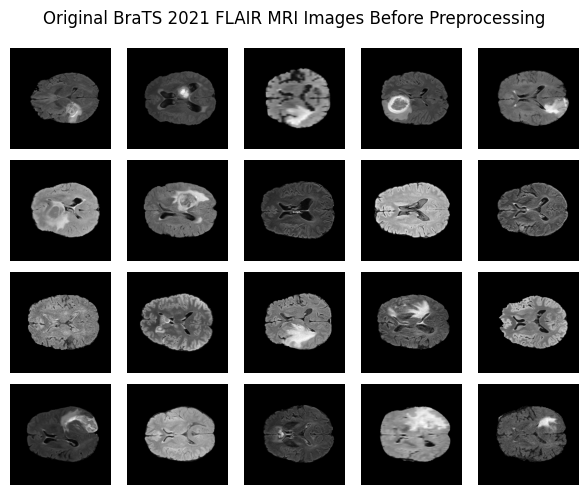

In [53]:
# ============================
# Display 20 Raw MRI Images
# Without Preprocessing
# ============================

import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


extract_path = "/kaggle/working/brats2021"


# Get patient folders
patient_folders = sorted([
    f for f in os.listdir(extract_path)
    if os.path.isdir(os.path.join(extract_path, f))
    and "BraTS" in f
])


# Randomly select 20 patients
patients = np.random.choice(
    patient_folders,
    20,
    replace=False
)


plt.figure(figsize=(6,5))


for i, patient in enumerate(patients):

    patient_path = os.path.join(
        extract_path,
        patient
    )


    # Find FLAIR image
    flair_file = [
        f for f in os.listdir(patient_path)
        if "flair" in f.lower()
    ][0]


    flair_path = os.path.join(
        patient_path,
        flair_file
    )


    # Load original 3D MRI volume
    flair_volume = nib.load(flair_path).get_fdata()


    # Take middle axial slice
    slice_index = flair_volume.shape[2] // 2

    img = flair_volume[:, :, slice_index]


    plt.subplot(4,5,i+1)

    plt.imshow(
        img,
        cmap="gray"
    )

    plt.axis("off")


plt.suptitle(
    "Original BraTS 2021 FLAIR MRI Images Before Preprocessing",
    fontsize=12
)

plt.tight_layout()
plt.show()

# Preprocess same as WGAN-GP. But filterning is slightly less than WGAN and DCGAN. We need more images for CGAN. since we are going to divided in two label. Small tumor and Large tumor images

In [2]:
# ============================
# 1️⃣ Imports
# ============================
import os
import nibabel as nib
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 128

extract_path = "/kaggle/working/brats2021"

input_images = []
tumor_sizes = []

# ============================
# 2️⃣ Normalize Function
# ============================
def normalize(img):
    img = img.astype(np.float32)
    img = (img - np.mean(img)) / (np.std(img)+1e-8)
    img = (img - img.min())/(img.max()-img.min()+1e-8)
    return img * 2 - 1

# ============================
# 3️⃣ Load ALL Patients
# ============================
patient_folders = sorted([
    f for f in os.listdir(extract_path)
    if os.path.isdir(os.path.join(extract_path, f)) and "BraTS" in f
])

print("Total patients:", len(patient_folders))

# ============================
# 4️⃣ Process Data
# ============================
for patient in tqdm(patient_folders):
    ppath = os.path.join(extract_path, patient)
    files = os.listdir(ppath)

    flair_path = [f for f in files if "flair" in f][0]
    seg_path   = [f for f in files if "seg" in f][0]

    flair_img = nib.load(os.path.join(ppath, flair_path)).get_fdata()
    seg_img   = nib.load(os.path.join(ppath, seg_path)).get_fdata()

    # Use middle slices only (avoid empty top/bottom)
    start = int(flair_img.shape[2] * 0.2)
    end   = int(flair_img.shape[2] * 0.8)

    for i in range(start, end):
        slice_img = flair_img[:, :, i]
        slice_seg = seg_img[:, :, i]

        # ------------------------
        # ❌ Remove empty slices
        # ------------------------
        if np.sum(slice_img > 0) < 500:
            continue

        # ------------------------
        # ❌ Remove very small tumor
        # ------------------------
        tumor_area = np.sum(slice_seg > 0)
        if tumor_area < 300:   # threshold (tune if needed)
            continue

        # ------------------------
        # Crop brain region
        # ------------------------
        coords = np.argwhere(slice_img > np.percentile(slice_img, 5))
        if coords.shape[0] == 0:
            continue

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        pad = 10
        y_min = max(0, y_min - pad)
        x_min = max(0, x_min - pad)
        y_max = min(slice_img.shape[0], y_max + pad)
        x_max = min(slice_img.shape[1], x_max + pad)

        crop_img = slice_img[y_min:y_max, x_min:x_max]
        crop_seg = slice_seg[y_min:y_max, x_min:x_max]

        # ------------------------
        # Resize
        # ------------------------
        img = cv2.resize(crop_img, (IMG_SIZE, IMG_SIZE))
        segm = cv2.resize(crop_seg, (IMG_SIZE, IMG_SIZE))

        # ------------------------
        # Normalize
        # ------------------------
        img = normalize(img)

        input_images.append(img[..., None])
        tumor_sizes.append(np.sum(segm > 0))

# Convert to numpy
input_images = np.array(input_images, dtype="float32")
tumor_sizes = np.array(tumor_sizes)

print("Final dataset shape:", input_images.shape)

Total patients: 1251


100%|██████████| 1251/1251 [05:48<00:00,  3.59it/s]


Final dataset shape: (64148, 128, 128, 1)


# Based on Median tumor value we split in two class. Each has 32k image. and DCGAN and WGAN has 41k. We try to balance as much as possible. But each GAN is different so necessary changes must take place.

In [3]:
# ============================
# 1️⃣ Define Threshold
# ============================
# Use median tumor size as threshold
threshold = np.median(tumor_sizes)

# ============================
# 2️⃣ Split Dataset
# ============================
small_indices = np.where(tumor_sizes < threshold)[0]
large_indices = np.where(tumor_sizes >= threshold)[0]

small_images = input_images[small_indices]

large_images = input_images[large_indices]

# ============================
# 3️⃣ Print Counts
# ============================
print("Total Images:", len(input_images))
print("Small Tumor Images:", len(small_images))
print("Large Tumor Images:", len(large_images))

Total Images: 64148
Small Tumor Images: 32058
Large Tumor Images: 32090


# Some images of both classes

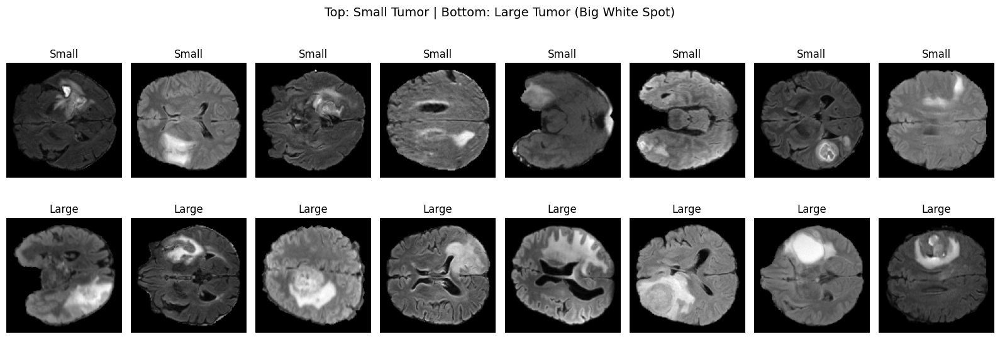

In [4]:
import matplotlib.pyplot as plt
import random

num_samples = 8

# Randomly pick samples
small_samples = random.sample(range(len(small_images)), num_samples)
large_samples = random.sample(range(len(large_images)), num_samples)

plt.figure(figsize=(16, 6))

# 🔹 Row 1: Small Tumors
for i, idx in enumerate(small_samples):
    img = (small_images[idx] + 1) / 2  # scale to [0,1]
    
    plt.subplot(2, num_samples, i+1)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Small")
    plt.axis('off')

# 🔹 Row 2: Large Tumors
for i, idx in enumerate(large_samples):
    img = (large_images[idx] + 1) / 2
    
    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Large")
    plt.axis('off')

plt.suptitle("Top: Small Tumor | Bottom: Large Tumor (Big White Spot)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import random

num_samples = 8

# Randomly pick samples
small_samples = random.sample(range(len(small_images)), num_samples)
large_samples = random.sample(range(len(large_images)), num_samples)

plt.figure(figsize=(16, 6))

# 🔹 Row 1: Small Tumors
for i, idx in enumerate(small_samples):
    img = (small_images[idx] + 1) / 2  # scale to [0,1]
    
    plt.subplot(2, num_samples, i+1)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Small")
    plt.axis('off')

# 🔹 Row 2: Large Tumors
for i, idx in enumerate(large_samples):
    img = (large_images[idx] + 1) / 2
    
    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Large")
    plt.axis('off')

plt.suptitle("Top: Small Tumor | Bottom: Large Tumor (Big White Spot)", fontsize=14)
plt.tight_layout()
plt.show()

# Use concatenate to merge both class and apply one-hot encoder

In [4]:
import tensorflow as tf
import numpy as np
from IPython.display import clear_output


# Combine both datasets
input_images = np.concatenate([small_images, large_images], axis=0)

# Labels: 0 = small, 1 = large
labels_bin = np.array([0]*len(small_images) + [1]*len(large_images))

# Shuffle
idx = np.random.permutation(len(input_images))
input_images = input_images[idx]
labels_bin = labels_bin[idx]

# One-hot encode
labels_onehot = tf.one_hot(labels_bin, depth=2)

# Dataset
BATCH_SIZE = 32
dataset = tf.data.Dataset.from_tensor_slices((input_images, labels_onehot))
dataset = dataset.shuffle(5000).batch(BATCH_SIZE)

print("Final dataset:", input_images.shape)
print("Label count:", np.bincount(labels_bin))

2026-07-10 10:07:10.237917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783678030.450815      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783678030.506760      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783678031.029991      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783678031.030017      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783678031.030021      57 computation_placer.cc:177] computation placer alr

Final dataset: (64148, 128, 128, 1)
Label count: [32058 32090]


# Generator same as WGAN-GP

In [5]:
from tensorflow.keras import layers

z_dim = 100
num_classes = 2
IMG_SIZE = 128

def build_generator():
    noise = layers.Input(shape=(z_dim,))
    label = layers.Input(shape=(num_classes,))
    
    x = layers.Concatenate()([noise, label])

    x = layers.Dense(8*8*512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((8,8,512))(x)

    x = layers.Conv2DTranspose(256,4,2,'same',use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(128,4,2,'same',use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64,4,2,'same',use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    out = layers.Conv2DTranspose(1,4,2,'same',activation='tanh')(x)

    return tf.keras.Model([noise,label], out)

generator = build_generator()

# Discriminator Same


In [6]:
def build_discriminator():
    img = layers.Input(shape=(IMG_SIZE,IMG_SIZE,1))
    label = layers.Input(shape=(IMG_SIZE,IMG_SIZE,2))

    x = layers.Concatenate()([img,label])

    x = layers.Conv2D(64,4,2,'same')(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128,4,2,'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256,4,2,'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(512,4,2,'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1,4,1,'same')(x)

    return tf.keras.Model([img,label], out)

discriminator = build_discriminator()

# loss is BinaryCrossentropy
* learning rate G=1e-4,D=2e-4 and beta=0.5

In [7]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def gen_loss(fake):
    return bce(tf.ones_like(fake), fake)

def disc_loss(real, fake):
    return bce(tf.ones_like(real), real) + bce(tf.zeros_like(fake), fake)

g_opt = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
d_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# Training step

In [8]:
@tf.function
def train_step(images, labels):
    batch = tf.shape(images)[0]
    noise = tf.random.normal([batch, z_dim])

    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake = generator([noise, labels], training=True)

        label_map = tf.reshape(labels, [batch,1,1,2])
        label_map = tf.tile(label_map, [1,IMG_SIZE,IMG_SIZE,1])

        real_out = discriminator([images,label_map], training=True)
        fake_out = discriminator([fake,label_map], training=True)

        g_loss = gen_loss(fake_out)
        d_loss = disc_loss(real_out, fake_out)

    g_opt.apply_gradients(zip(gt.gradient(g_loss, generator.trainable_variables),
                              generator.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(d_loss, discriminator.trainable_variables),
                              discriminator.trainable_variables))
    
    return g_loss, d_loss

In [9]:
import matplotlib.pyplot as plt

def generate_images(epoch):
    noise = tf.random.normal([2, z_dim])
    labels = tf.one_hot([0,1], depth=2)  # small vs large

    imgs = generator([noise, labels], training=False)
    imgs = (imgs+1)/2

    plt.figure(figsize=(6,3))
    for i in range(2):
        plt.subplot(1,2,i+1)
        plt.imshow(imgs[i,:,:,0], cmap='gray')
        plt.title("Small Tumor" if i==0 else "Large Tumor")
        plt.axis('off')
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

# Training loop
# each epoch time 4 min 24 sec

G Loss: 0.7089 | D Loss: 1.3914
No improvement: 2/10


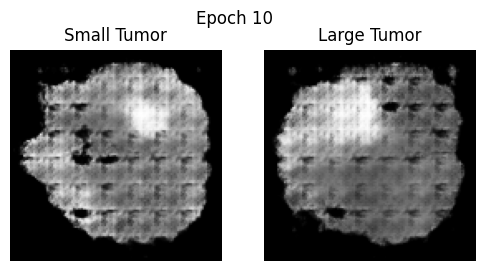


Epoch 11/14


 70%|███████   | 1409/2005 [03:19<01:24,  7.06it/s]


KeyboardInterrupt: 

In [10]:
from tqdm import tqdm

EPOCHS = 14
PATIENCE = 10

best_g_loss = np.inf
wait = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    g_losses = []
    d_losses = []

    for img_batch, lab_batch in tqdm(dataset):
        g_loss, d_loss = train_step(img_batch, lab_batch)

        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())

    avg_g = np.mean(g_losses)
    avg_d = np.mean(d_losses)
    
    clear_output(wait=True)

    print(f"G Loss: {avg_g:.4f} | D Loss: {avg_d:.4f}")

    # 🔥 Early stopping
    if avg_g < best_g_loss:
        best_g_loss = avg_g
        wait = 0
        generator.save("best_generator.h5")
        print("✅ Best model saved")
    else:
        wait += 1
        print(f"No improvement: {wait}/{PATIENCE}")

        if wait >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

    generate_images(epoch+1)

# additional

In [11]:
import tensorflow as tf
import numpy as np

generator = tf.keras.models.load_model(
    "/kaggle/working/best_generator.h5",
    compile=False
)

print("Generator loaded successfully!")

Generator loaded successfully!


In [12]:
NUM_IMAGES = 2000
HALF = NUM_IMAGES // 2

z_dim = 100

# Random noise
noise_small = tf.random.normal([HALF, z_dim])
noise_large = tf.random.normal([HALF, z_dim])

# Labels
label_small = tf.one_hot(np.zeros(HALF, dtype=np.int32), depth=2)
label_large = tf.one_hot(np.ones(HALF, dtype=np.int32), depth=2)

# Generate images
fake_small = generator([noise_small, label_small], training=False)
fake_large = generator([noise_large, label_large], training=False)

# Combine
generated_images = tf.concat([fake_small, fake_large], axis=0)

print("Generated shape:", generated_images.shape)

Generated shape: (2000, 128, 128, 1)


In [13]:
generated_images = generated_images.numpy()

idx = np.random.permutation(len(generated_images))
generated_images = generated_images[idx]

In [14]:
np.save("/kaggle/working/generated_images_2000.npy", generated_images)

print("Saved successfully!")

Saved successfully!


In [15]:
imgs = np.load("/kaggle/working/generated_images_2000.npy")
print(imgs.shape)
print(imgs.min(), imgs.max())

(2000, 128, 128, 1)
-1.0 0.99943435


In [16]:
labels = np.concatenate([
    np.zeros(HALF, dtype=np.int32),   # small
    np.ones(HALF, dtype=np.int32)     # large
])

labels = labels[idx]

np.save("/kaggle/working/generated_labels_2000.npy", labels)

print("Images and labels saved.")

Images and labels saved.


# Extra. Not Count

In [ ]:
TOTAL_IMAGES = 2000
BATCH_GEN = 32

all_images = []

steps = TOTAL_IMAGES // BATCH_GEN + int(TOTAL_IMAGES % BATCH_GEN != 0)

for step in range(steps):
    current_batch = min(BATCH_GEN, TOTAL_IMAGES - len(all_images)*BATCH_GEN)

    # -------------------------
    # Create balanced labels
    # -------------------------
    half = current_batch // 2
    labels = np.array([0]*half + [1]*(current_batch - half))
    np.random.shuffle(labels)

    labels_onehot = tf.one_hot(labels, depth=2)

    # -------------------------
    # Generate images
    # -------------------------
    noise = tf.random.normal([current_batch, z_dim])
    fake_images = generator([noise, labels_onehot], training=False)

    all_images.append(fake_images.numpy())

    print(f"Generated batch {step+1}/{steps}")

In [ ]:
generated_images = np.concatenate(all_images, axis=0)

print("Final shape:", generated_images.shape)

In [ ]:
np.save("generated_images_128.npy", generated_images)
print("✅ Saved successfully!")

In [ ]:
data = np.load("/kaggle/input/datasets/shantaakterid170/generated-cgan/generated_images_128 (8).npy")

print("Shape:", data.shape)
print("Min:", data.min(), "Max:", data.max())

# Extra. Not count. 

In [ ]:
indices = np.random.choice(len(data), 20, replace=False)

plt.figure(figsize=(10,8))

for i, idx in enumerate(indices):
    plt.subplot(4,5,i+1)
    
    img = data[idx].squeeze()
    img = (img + 1) / 2
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

# Generate 1000 small tumor and 1000 large tumor images

In [12]:
TOTAL_IMAGES = 2000
BATCH_GEN = 32

all_images = []
all_labels = []   # ✅ ADD THIS

steps = TOTAL_IMAGES // BATCH_GEN + int(TOTAL_IMAGES % BATCH_GEN != 0)

generated_count = 0  # ✅ better tracking

for step in range(steps):
    current_batch = min(BATCH_GEN, TOTAL_IMAGES - generated_count)

    # -------------------------
    # Create balanced labels
    # -------------------------
    half = current_batch // 2
    labels = np.array([0]*half + [1]*(current_batch - half))
    np.random.shuffle(labels)

    labels_onehot = tf.one_hot(labels, depth=2)

    # -------------------------
    # Generate images
    # -------------------------
    noise = tf.random.normal([current_batch, z_dim])
    fake_images = generator([noise, labels_onehot], training=False)

    # ✅ STORE BOTH
    all_images.append(fake_images.numpy())
    all_labels.append(labels)

    generated_count += current_batch

    print(f"Generated batch {step+1}/{steps}")

# -------------------------
# Combine
# -------------------------
generated_images = np.concatenate(all_images, axis=0)
generated_labels = np.concatenate(all_labels, axis=0)

print("Images shape:", generated_images.shape)
print("Labels shape:", generated_labels.shape)

# -------------------------
# Save BOTH
# -------------------------
np.save("generated_images_128.npy", generated_images)
np.save("generated_labels.npy", generated_labels)

print("✅ Images + Labels saved successfully!")

Generated batch 1/63
Generated batch 2/63
Generated batch 3/63
Generated batch 4/63
Generated batch 5/63
Generated batch 6/63
Generated batch 7/63
Generated batch 8/63
Generated batch 9/63
Generated batch 10/63
Generated batch 11/63
Generated batch 12/63
Generated batch 13/63
Generated batch 14/63
Generated batch 15/63
Generated batch 16/63
Generated batch 17/63
Generated batch 18/63
Generated batch 19/63
Generated batch 20/63
Generated batch 21/63
Generated batch 22/63
Generated batch 23/63
Generated batch 24/63
Generated batch 25/63
Generated batch 26/63
Generated batch 27/63
Generated batch 28/63
Generated batch 29/63
Generated batch 30/63
Generated batch 31/63
Generated batch 32/63
Generated batch 33/63
Generated batch 34/63
Generated batch 35/63
Generated batch 36/63
Generated batch 37/63
Generated batch 38/63
Generated batch 39/63
Generated batch 40/63
Generated batch 41/63
Generated batch 42/63
Generated batch 43/63
Generated batch 44/63
Generated batch 45/63
Generated batch 46/

# Generated images

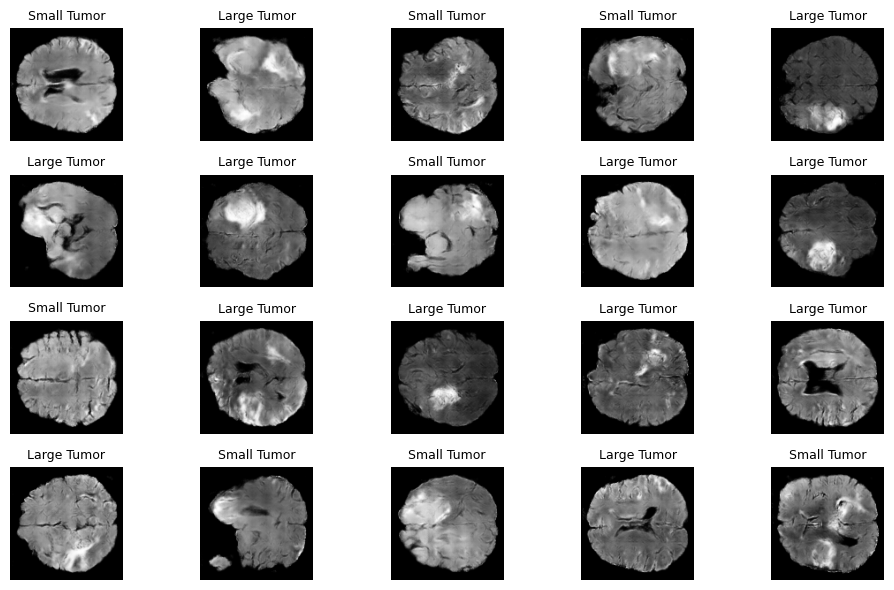

In [17]:
# new
import numpy as np
import matplotlib.pyplot as plt

# Load saved data
images = np.load("/kaggle/working/generated_images_2000.npy")
labels = np.load("/kaggle/working/generated_labels_2000.npy")

plt.figure(figsize=(10,6))

for i in range(20):
    plt.subplot(4,5,i+1)

    # Get image and normalize
    img = images[i].squeeze()
    img = (img + 1) / 2   # [-1,1] → [0,1]

    # Get label text
    label_text = "Small Tumor" if labels[i] == 0 else "Large Tumor"

    plt.imshow(img, cmap='gray')
    plt.title(label_text, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Extra. Not count. early stages images

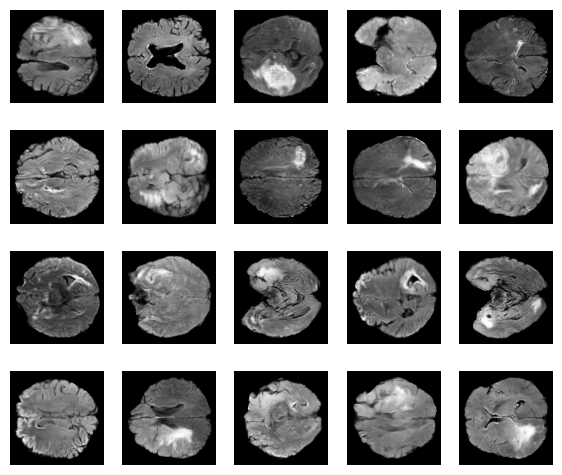

In [46]:
# new
generated_images = np.load("/kaggle/input/datasets/shantaakterid170/generated-cgan/generated_images_128 (8).npy")

indices = np.random.choice(len(generated_images), 20, replace=False)

plt.figure(figsize=(7,6))

for i, idx in enumerate(indices):
    plt.subplot(4,5,i+1)
    
    img = generated_images[idx].squeeze()
    img = (img + 1) / 2
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

In [48]:

generated_images = np.load("/kaggle/working/brats2021")


indices = np.random.choice(len(generated_images), 20, replace=False)

plt.figure(figsize=(7,6))

for i, idx in enumerate(indices):
    plt.subplot(4,5,i+1)
    
    img = generated_images[idx].squeeze()
    img = (img + 1) / 2
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

IsADirectoryError: [Errno 21] Is a directory: '/kaggle/working/brats2021'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved data
images = np.load("generated_images_128.npy")
labels = np.load("generated_labels.npy")

plt.figure(figsize=(10,8))

for i in range(20):
    plt.subplot(4,5,i+1)

    # Get image and normalize
    img = images[i].squeeze()
    img = (img + 1) / 2   # [-1,1] → [0,1]

    # Get label text
    label_text = "Small Tumor" if labels[i] == 0 else "Large Tumor"

    plt.imshow(img, cmap='gray')
    plt.title(label_text, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
import numpy as np

# Set seed for reproducibility (optional)
np.random.seed(42)

# Randomly select 2000 indices
idx = np.random.choice(len(input_images), 2000, replace=False)

real_subset = input_images[idx]
fake_images=images[:2000]

print("Subset shape:", real_subset.shape)

Subset shape: (2000, 128, 128, 1)


In [19]:
real_images = real_subset   # from your preprocessing code

# fake_images = np.load("/kaggle/working/generated_images_128.npy")

print("Real:", real_images.shape)
print("Fake:", fake_images.shape)

Real: (2000, 128, 128, 1)
Fake: (2000, 128, 128, 1)


In [20]:
print("Shape:", fake_images.shape)
print("Min:", fake_images.min(), "Max:", fake_images.max())

Shape: (2000, 128, 128, 1)
Min: -1.0 Max: 0.99943435


In [21]:
print("Shape:", real_images.shape)
print("Min:", real_images.min(), "Max:", real_images.max())

Shape: (2000, 128, 128, 1)
Min: -1.0 Max: 1.0


In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import preprocess_input

def preprocess_images(images):
    # assume images are in [-1,1]
    images = (images + 1.0) * 127.5
    
    # grayscale → RGB
    images = np.repeat(images, 3, axis=-1)
    
    # resize to 299x299
    images = tf.image.resize(images, (299, 299)).numpy()
    
    return preprocess_input(images)

real_proc = preprocess_images(real_images)
fake_proc = preprocess_images(fake_images)

In [23]:
from tensorflow.keras.applications import InceptionV3

model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [24]:
real_features = model.predict(real_proc, batch_size=32, verbose=1)
fake_features = model.predict(fake_proc, batch_size=32, verbose=1)

I0000 00:00:1783681836.086182     136 service.cc:152] XLA service 0x7daad8094060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783681836.086237     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783681836.086241     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 1/63 ━━━━━━━━━━━━━━━━━━━━ 12:49 12s/step

I0000 00:00:1783681846.087263     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 260ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step


# FID score for best training.

In [25]:
from scipy import linalg

def calculate_fid(f1, f2):
    mu1, sigma1 = f1.mean(axis=0), np.cov(f1, rowvar=False)
    mu2, sigma2 = f2.mean(axis=0), np.cov(f2, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

fid_score = calculate_fid(real_features, fake_features)
print("🎯 FID Score:", fid_score)

/tmp/ipykernel_57/1112370879.py:8: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


🎯 FID Score: 52.53607145130165


# Inital FID score .not great.

In [ ]:
from scipy import linalg

def calculate_fid(f1, f2):
    mu1, sigma1 = f1.mean(axis=0), np.cov(f1, rowvar=False)
    mu2, sigma2 = f2.mean(axis=0), np.cov(f2, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

fid_score = calculate_fid(real_features, fake_features)
print("🎯 FID Score:", fid_score)

# IS score

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import preprocess_input

def preprocess_images(images):
    # [-1,1] → [0,255]
    images = (images + 1.0) * 127.5
    
    # grayscale → RGB
    images = np.repeat(images, 3, axis=-1)
    
    # resize
    images = tf.image.resize(images, (299, 299)).numpy()
    
    return preprocess_input(images)

fake_proc = preprocess_images(fake_images)

In [27]:
from tensorflow.keras.applications import InceptionV3

model = InceptionV3(include_top=True, weights='imagenet')

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [28]:
preds = model.predict(fake_proc, batch_size=16, verbose=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step


In [29]:
# new
import numpy as np
from scipy.stats import entropy

def calculate_inception_score(preds, splits=10):
    scores = []
    N = preds.shape[0]
    
    for i in range(splits):
        part = preds[i * N // splits : (i + 1) * N // splits]
        
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        kl_sum = np.mean(np.sum(kl, axis=1))
        
        scores.append(np.exp(kl_sum))
    
    return np.mean(scores), np.std(scores)

is_mean, is_std = calculate_inception_score(preds)

print(f"🎯 Inception Score: {is_mean:.4f} ± {is_std:.4f}")

🎯 Inception Score: 2.1629 ± 0.0575


In [ ]:
import numpy as np
from scipy.stats import entropy

def calculate_inception_score(preds, splits=10):
    scores = []
    N = preds.shape[0]
    
    for i in range(splits):
        part = preds[i * N // splits : (i + 1) * N // splits]
        
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        kl_sum = np.mean(np.sum(kl, axis=1))
        
        scores.append(np.exp(kl_sum))
    
    return np.mean(scores), np.std(scores)

is_mean, is_std = calculate_inception_score(preds)

print(f"🎯 Inception Score: {is_mean:.4f} ± {is_std:.4f}")

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 8 random images
idx_real = np.random.choice(len(real_images), 8, replace=False)
idx_fake = np.random.choice(len(fake_images), 8, replace=False)

real_sample = real_images[idx_real]
fake_sample = fake_images[idx_fake]

# Plot
plt.figure(figsize=(10, 8))

# -----------------------
# Real Images (Top Row)
# -----------------------
for i in range(8):
    plt.subplot(4, 4, i + 1)
    plt.imshow(real_sample[i].squeeze(), cmap='gray')
    plt.title("Real")
    plt.axis('off')

# -----------------------
# Fake Images (Bottom Row)
# -----------------------
for i in range(8):
    plt.subplot(4, 4, 8 + i + 1)
    plt.imshow(fake_sample[i].squeeze(), cmap='gray')
    plt.title("Fake")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Extra. Early stages

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select 8 random images
idx_real = np.random.choice(len(real_images), 8, replace=False)
idx_fake = np.random.choice(len(fake_images), 8, replace=False)

real_sample = real_images[idx_real]
fake_sample = fake_images[idx_fake]

# Plot
plt.figure(figsize=(12, 6))

# -----------------------
# Real Images (Top Row)
# -----------------------
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(real_sample[i].squeeze(), cmap='gray')
    plt.title("Real")
    plt.axis('off')

# -----------------------
# Fake Images (Bottom Row)
# -----------------------
for i in range(8):
    plt.subplot(2, 8, 8 + i + 1)
    plt.imshow(fake_sample[i].squeeze(), cmap='gray')
    plt.title("Fake")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Some generated images

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(8,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(10,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(10,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Extra. Early stages images

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(10, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Data
epochs = [11, 12, 13, 14, 15, 16]
fid_scores = [91.49, 81.12, 84.87, 76.26, 83.10, 81.97]

# Plot
plt.figure()
plt.plot(epochs, fid_scores, marker='o')

plt.xlabel("Epoch")
plt.ylabel("FID Score")
plt.title("FID Score vs Epoch (WGAN)")

plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Data
epochs = [11, 12, 13, 14, 15, 16]
is_scores = [1.9856, 2.0613, 2.1334, 2.1967, 2.2324, 2.0758]

# Plot
plt.figure()
plt.plot(epochs, is_scores, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Inception Score")
plt.title("Inception Score vs Epoch (WGAN)")

plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Data
epochs = [11, 12, 13, 14, 15, 16]
is_scores = [1.9856, 2.0613, 2.1334, 2.1967, 2.2324, 2.0758]

# Plot
plt.figure()
plt.plot(epochs, is_scores, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Inception Score")
plt.title("Inception Score vs Epoch (WGAN)")

plt.grid()
plt.show()

In [ ]:
plt.savefig("fid_vs_epoch.png")
plt.savefig("is_vs_epoch.png")

In [ ]:
import matplotlib.pyplot as plt

models = ["DCGAN", "CGAN", "WGAN"]
fid_scores = [60.49, 34.06, 76.26]

plt.figure()
plt.bar(models, fid_scores)

plt.xlabel("Model")
plt.ylabel("FID Score")
plt.title("FID Comparison Across GAN Models")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

models = ["DCGAN", "CGAN", "WGAN"]
is_scores = [2.3527, 2.2573, 2.2324]

plt.figure()
plt.bar(models, is_scores)

plt.xlabel("Model")
plt.ylabel("Inception Score")
plt.title("Inception Score Comparison Across GAN Models")

plt.show()

# segmentation

In [2]:
# ============================
# Imports
# ============================
import os
import nibabel as nib
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 128
MAX_IMAGES = 4000

extract_path = "/kaggle/working/brats2021"

input_images = []
input_masks = []
tumor_sizes = []

# ============================
# Normalize Function
# ============================
def normalize(img):
    img = img.astype(np.float32)
    img = (img - np.mean(img)) / (np.std(img) + 1e-8)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img * 2 - 1

# ============================
# Patient folders
# ============================
patient_folders = sorted([
    f for f in os.listdir(extract_path)
    if os.path.isdir(os.path.join(extract_path, f)) and "BraTS" in f
])

print("Total patients:", len(patient_folders))

# ============================
# Process Images
# ============================
for patient in tqdm(patient_folders):

    if len(input_images) >= MAX_IMAGES:
        break

    ppath = os.path.join(extract_path, patient)
    files = os.listdir(ppath)

    flair_path = [f for f in files if "flair" in f][0]
    seg_path = [f for f in files if "seg" in f][0]

    flair_img = nib.load(os.path.join(ppath, flair_path)).get_fdata()
    seg_img = nib.load(os.path.join(ppath, seg_path)).get_fdata()

    start = int(flair_img.shape[2] * 0.2)
    end = int(flair_img.shape[2] * 0.8)

    for i in range(start, end):

        if len(input_images) >= MAX_IMAGES:
            break

        slice_img = flair_img[:, :, i]
        slice_seg = seg_img[:, :, i]

        # Remove empty slices
        if np.sum(slice_img > 0) < 500:
            continue

        # Remove very small tumors
        tumor_area = np.sum(slice_seg > 0)
        if tumor_area < 300:
            continue

        # Crop brain region
        coords = np.argwhere(slice_img > np.percentile(slice_img, 5))

        if len(coords) == 0:
            continue

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        pad = 10

        y_min = max(0, y_min - pad)
        x_min = max(0, x_min - pad)
        y_max = min(slice_img.shape[0], y_max + pad)
        x_max = min(slice_img.shape[1], x_max + pad)

        crop_img = slice_img[y_min:y_max, x_min:x_max]
        crop_seg = slice_seg[y_min:y_max, x_min:x_max]

        # Resize image
        img = cv2.resize(
            crop_img,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_LINEAR
        )

        # Resize mask (VERY IMPORTANT)
        mask = cv2.resize(
            crop_seg,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        # Binary mask
        mask = (mask > 0).astype(np.float32)

        # Normalize MRI
        img = normalize(img)

        input_images.append(img[..., None])
        input_masks.append(mask[..., None])
        tumor_sizes.append(np.sum(mask))

# ============================
# Convert to numpy
# ============================
input_images = np.array(input_images, dtype=np.float32)
input_masks = np.array(input_masks, dtype=np.float32)
tumor_sizes = np.array(tumor_sizes)

print("Images :", input_images.shape)
print("Masks  :", input_masks.shape)
print("Tumors :", tumor_sizes.shape)

# Example:
# Images : (4000, 128, 128, 1)
# Masks  : (4000, 128, 128, 1)

Total patients: 1251


  6%|▌         | 78/1251 [00:19<04:46,  4.10it/s]

Images : (4000, 128, 128, 1)
Masks  : (4000, 128, 128, 1)
Tumors : (4000,)


# Step 1: Split Real Data into Train / Validation / Test

In [3]:
from sklearn.model_selection import train_test_split

# input_images = real MRI images (4000)
# input_masks  = real masks (4000)

# 80% Train+Val, 20% Test
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    input_images,
    input_masks,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# From Train+Val:
# 80% Train, 20% Validation

X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval,
    Y_trainval,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

Training   : (2560, 128, 128, 1)
Validation : (640, 128, 128, 1)
Test       : (800, 128, 128, 1)


# Step 2: Create Data Scarcity Dataset (10%)

In [4]:
from sklearn.model_selection import train_test_split

X_real10, _, Y_real10, _ = train_test_split(
    X_train,
    Y_train,
    train_size=320,
    random_state=42,
    shuffle=True
)

print(X_real10.shape)
print(Y_real10.shape)

(320, 128, 128, 1)
(320, 128, 128, 1)


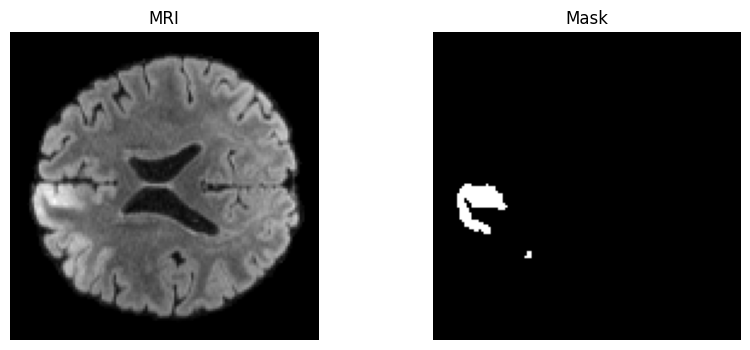

In [3]:
import matplotlib.pyplot as plt

idx = np.random.randint(len(input_images))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(input_images[idx].squeeze(), cmap='gray')
plt.title("MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(input_masks[idx].squeeze(), cmap='gray')
plt.title("Mask")
plt.axis("off")

plt.show()


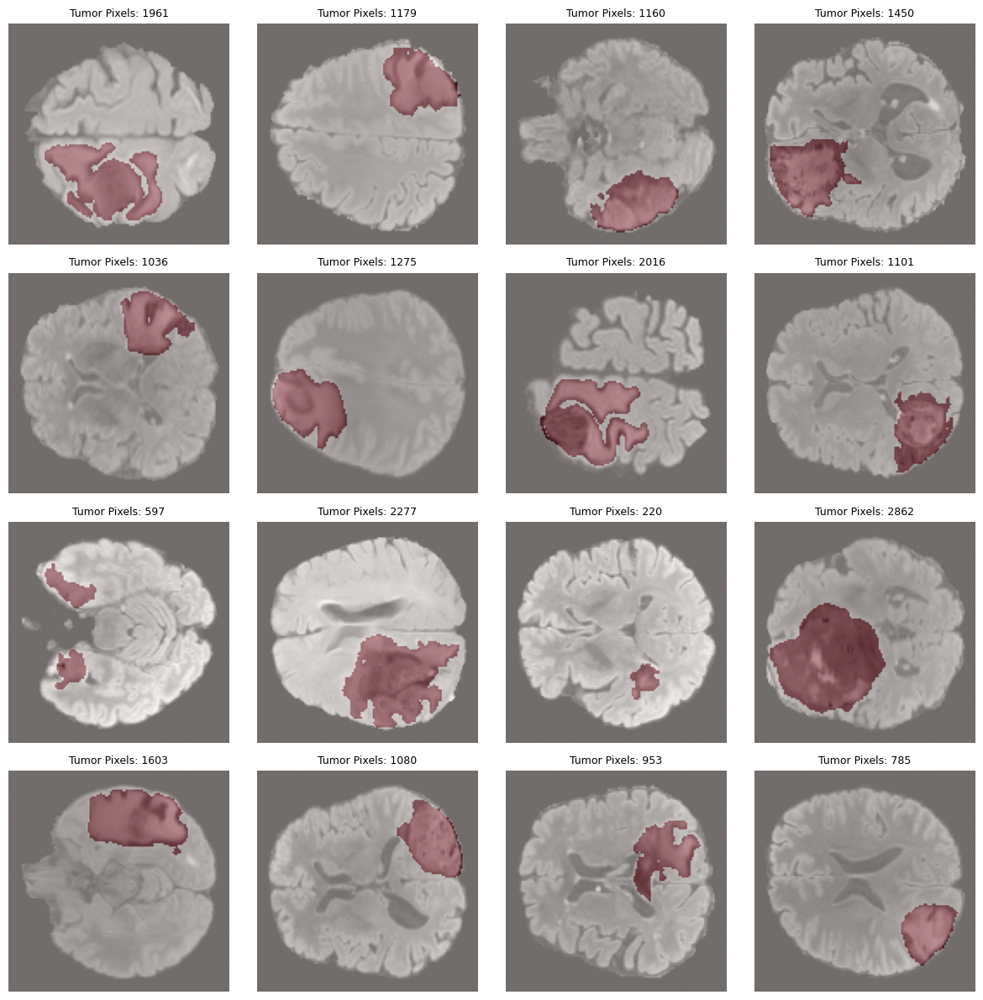

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Randomly select 16 images
indices = np.random.choice(len(input_images), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = input_images[idx].squeeze()
    mask = input_masks[idx].squeeze()

    # Display MRI
    ax.imshow(img, cmap='gray')

    # Overlay mask
    ax.imshow(mask, cmap='Reds', alpha=0.45)

    # Tumor size
    ax.set_title(f"Tumor Pixels: {int(mask.sum())}", fontsize=9)

    ax.axis('off')

plt.tight_layout()
plt.show()

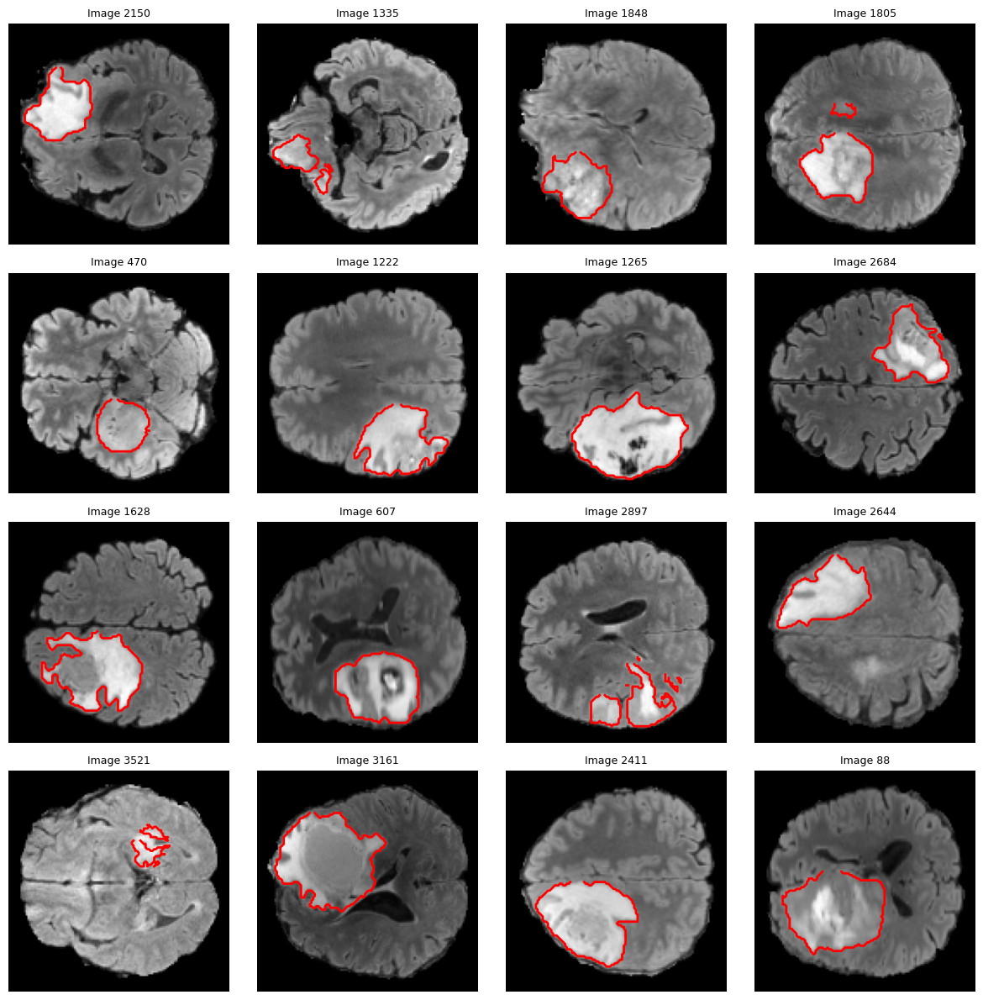

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(input_images), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = input_images[idx].squeeze()
    mask = input_masks[idx].squeeze().astype(np.uint8)

    ax.imshow(img, cmap='gray')

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours in red
    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color='red', linewidth=2)

    ax.set_title(f"Image {idx}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    input_images,
    input_masks,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(X_train.shape)
print(X_test.shape)

(3200, 128, 128, 1)
(800, 128, 128, 1)


In [5]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def conv_block(x, filters):

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

def encoder(x, filters):

    c = conv_block(x, filters)
    p = MaxPooling2D((2,2))(c)

    return c,p

def decoder(x, skip, filters):

    x = Conv2DTranspose(filters,2,strides=2,padding="same")(x)
    x = Concatenate()([x,skip])
    x = conv_block(x,filters)

    return x

def build_unet(input_shape=(128,128,1)):

    inputs = Input(input_shape)

    s1,p1 = encoder(inputs,64)
    s2,p2 = encoder(p1,128)
    s3,p3 = encoder(p2,256)
    s4,p4 = encoder(p3,512)

    b = conv_block(p4,1024)

    d1 = decoder(b,s4,512)
    d2 = decoder(d1,s3,256)
    d3 = decoder(d2,s2,128)
    d4 = decoder(d3,s1,64)

    outputs = Conv2D(1,1,activation="sigmoid")(d4)

    return Model(inputs,outputs)

model = build_unet()
model.summary()

2026-07-13 08:15:14.215206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783930514.621140      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783930514.719087      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783930515.819111      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783930515.819140      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783930515.819143      57 computation_placer.cc:177] computation placer alr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [6]:
import tensorflow as tf

smooth = 1e-6

def dice_coef(y_true,y_pred):

    y_true=tf.reshape(y_true,[-1])
    y_pred=tf.reshape(y_pred,[-1])

    intersection=tf.reduce_sum(y_true*y_pred)

    return (2.*intersection+smooth)/(tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)+smooth)

In [7]:
def dice_loss(y_true,y_pred):

    return 1-dice_coef(y_true,y_pred)

In [8]:
from tensorflow.keras.optimizers import Adam

def bce_dice_loss(y_true,y_pred):
    bce=tf.keras.losses.binary_crossentropy(y_true,y_pred)
    return bce+dice_loss(y_true,y_pred)

model.compile(
    optimizer=Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        tf.keras.metrics.BinaryIoU(target_class_ids=[1])
    ]
)

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks=[

    ModelCheckpoint(
        "best_unet.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True
    ),

    EarlyStopping(
        monitor="val_dice_coef",
        patience=10,
        mode="max",
        restore_best_weights=True
    )
]

# history=model.fit(

#     X_train,
#     Y_train,

#     validation_data=(X_test,Y_test),

#     epochs=50,

#     batch_size=16,
 
#     callbacks=callbacks
# )

In [12]:
model.evaluate(X_test,Y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - binary_io_u: 0.9383 - dice_coef: 0.9667 - loss: 0.0531


[0.05289177596569061, 0.9671282768249512, 0.939215898513794]

# Step 3: Train Baseline U-Net (320 Real Images)

In [14]:
small_model = build_unet()

small_model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        tf.keras.metrics.BinaryIoU(
            target_class_ids=[1]
        )
    ]
)

history_small = small_model.fit(
    X_real10,
    Y_real10,

    validation_data=(
        X_val,
        Y_val
    ),

    epochs=50,
    batch_size=16,

    callbacks=callbacks
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 650ms/step - binary_io_u_3: 0.3376 - dice_coef: 0.3549 - loss: 1.0377 - val_binary_io_u_3: 0.0715 - val_dice_coef: 0.1332 - val_loss: 2334.4966
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 472ms/step - binary_io_u_3: 0.7338 - dice_coef: 0.6357 - loss: 0.4814 - val_binary_io_u_3: 0.0715 - val_dice_coef: 0.1332 - val_loss: 2138.4526
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 501ms/step - binary_io_u_3: 0.7264 - dice_coef: 0.6849 - loss: 0.4101 - val_binary_io_u_3: 0.0715 - val_dice_coef: 0.1332 - val_loss: 4221.5898
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 519ms/step - binary_io_u_3: 0.7629 - dice_coef: 0.7505 - loss: 0.3251 - val_binary_io_u_3: 0.0715 - val_dice_coef: 0.1332 - val_loss: 1593.1423
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 604ms/step - binary_io_u_3: 0.7726 - dice_coef: 0.7893 - loss: 0.2765 - val_binary_io_u_3: 0.0740 - val_dice_coef: 0.1376 - val_loss: 82.5771
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 561ms/step - binary_io_u_3: 0.7

# Step 4: Evaluate Baseline

In [15]:
baseline_results = small_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("===== Baseline U-Net (320 Real Images) =====")
print(f"Loss : {baseline_results[0]:.4f}")
print(f"Dice : {baseline_results[1]:.4f}")
print(f"IoU  : {baseline_results[2]:.4f}")

===== Baseline U-Net (320 Real Images) =====
Loss : 0.1358
Dice : 0.9101
IoU  : 0.8460


# For 3200 images

In [13]:
results = model.evaluate(X_test, Y_test, verbose=0)

loss = results[0]
dice = results[1]
iou = results[2]

print("="*40)
print("U-Net Evaluation on Test Set")
print("="*40)
print(f"Loss             : {loss:.4f}")
print(f"Dice Coefficient : {dice:.4f}")
print(f"Binary IoU       : {iou:.4f}")
print("="*40)

U-Net Evaluation on Test Set
Loss             : 0.0529
Dice Coefficient : 0.9671
Binary IoU       : 0.9392


# Synthetic images of cGAN

In [15]:
synthetic=np.load("/kaggle/input/datasets/shantaakterid170/generated-cgan/generated_images_128 (8).npy")

print(synthetic.shape)

# (2000,128,128,1)

(2000, 128, 128, 1)


# Synthetic of DCGAN

In [24]:
DCGAN_synthetic=np.load("/kaggle/input/datasets/shantaakterid170/dcgan-best-result/generated_images_DCGAN_BEST.npy")

print(DCGAN_synthetic.shape)

# (2000,128,128,1)

(5024, 128, 128, 1)


# Synthetic WGAN

In [42]:
WGAN_synthetic=np.load("/kaggle/input/datasets/shantaakterid170/wgan-best/WGANgenerated_images7.npy")

print(WGAN_synthetic.shape)

# (2000,128,128,1)

(2000, 128, 128, 1)


In [44]:
WGAN_synthetic = WGAN_synthetic * 2 - 1

In [45]:
print(f"Min: {WGAN_synthetic.min():.4f}")
print(f"Max: {WGAN_synthetic.max():.4f}")

if synthetic.min() >= -1 and synthetic.max() <= 1:
    print("✅ Images are normalized to [-1, 1].")
else:
    print("❌ Images are NOT in the range [-1, 1].")

Min: -1.0000
Max: 0.9955
✅ Images are normalized to [-1, 1].


In [27]:
print(f"Min: {DCGAN_synthetic.min():.4f}")
print(f"Max: {DCGAN_synthetic.max():.4f}")

if synthetic.min() >= -1 and synthetic.max() <= 1:
    print("✅ Images are normalized to [-1, 1].")
else:
    print("❌ Images are NOT in the range [-1, 1].")

Min: -1.0000
Max: 0.9988
✅ Images are normalized to [-1, 1].


In [26]:
DCGAN_synthetic = DCGAN_synthetic * 2 - 1

# DCGAN

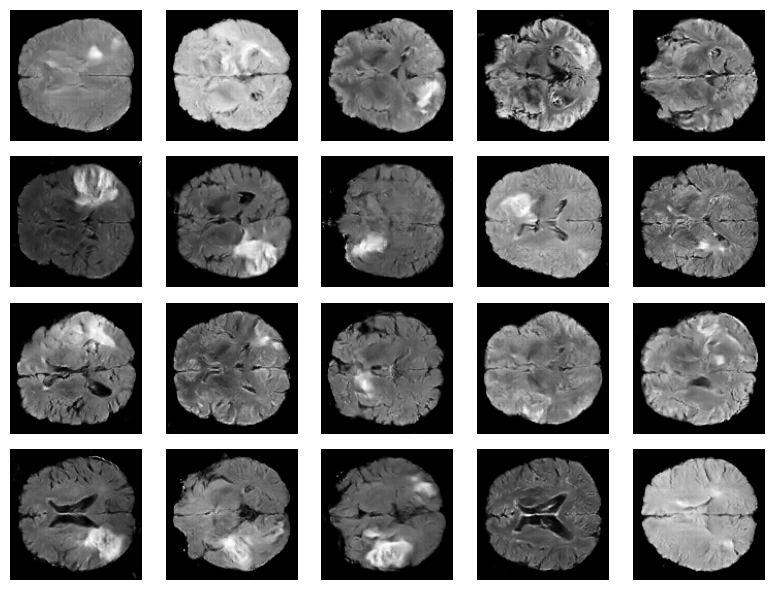

In [30]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(DCGAN_synthetic), 20, replace=False)
samples = DCGAN_synthetic[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(8,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# WGAN

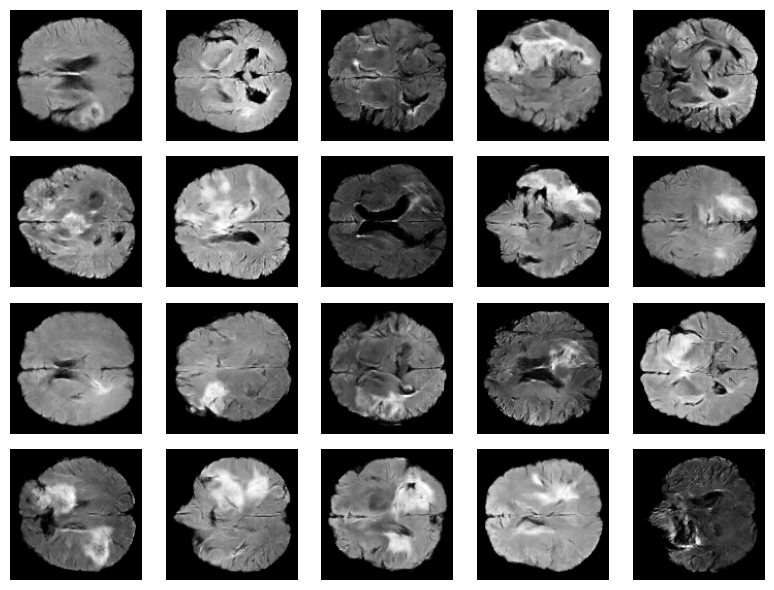

In [47]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(WGAN_synthetic), 20, replace=False)
samples = WGAN_synthetic[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(8,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# cGAN pseudo mask

In [17]:
pseudo_masks=model.predict(synthetic,batch_size=16)

print(pseudo_masks.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step
(2000, 128, 128, 1)


# DCGAN pseudo mask

In [33]:
import numpy as np

np.random.seed(42)  # For reproducibility

indices = np.random.choice(len(DCGAN_synthetic), 2000, replace=False)

synthetic2 = DCGAN_synthetic[indices]

print(synthetic2.shape)

(2000, 128, 128, 1)


In [34]:
DCGAN_masks=model.predict(synthetic2,batch_size=16)

print(DCGAN_masks.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step
(2000, 128, 128, 1)


In [35]:
DCGAN_masks=(DCGAN_masks>0.5).astype(np.uint8)

In [18]:
pseudo_masks=(pseudo_masks>0.5).astype(np.uint8)

In [36]:
np.save("DCGAN_masks.npy",DCGAN_masks)

In [38]:
np.save("DCGAN_synthetic_for_mask.npy",synthetic2)

# WGAN MASK

In [48]:
WGAN_masks=model.predict(WGAN_synthetic,batch_size=16)

print(WGAN_masks.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step
(2000, 128, 128, 1)


In [49]:
WGAN_masks=(WGAN_masks>0.5).astype(np.uint8)

In [50]:
np.save("WGAN_masks.npy",WGAN_masks)

# CGAN

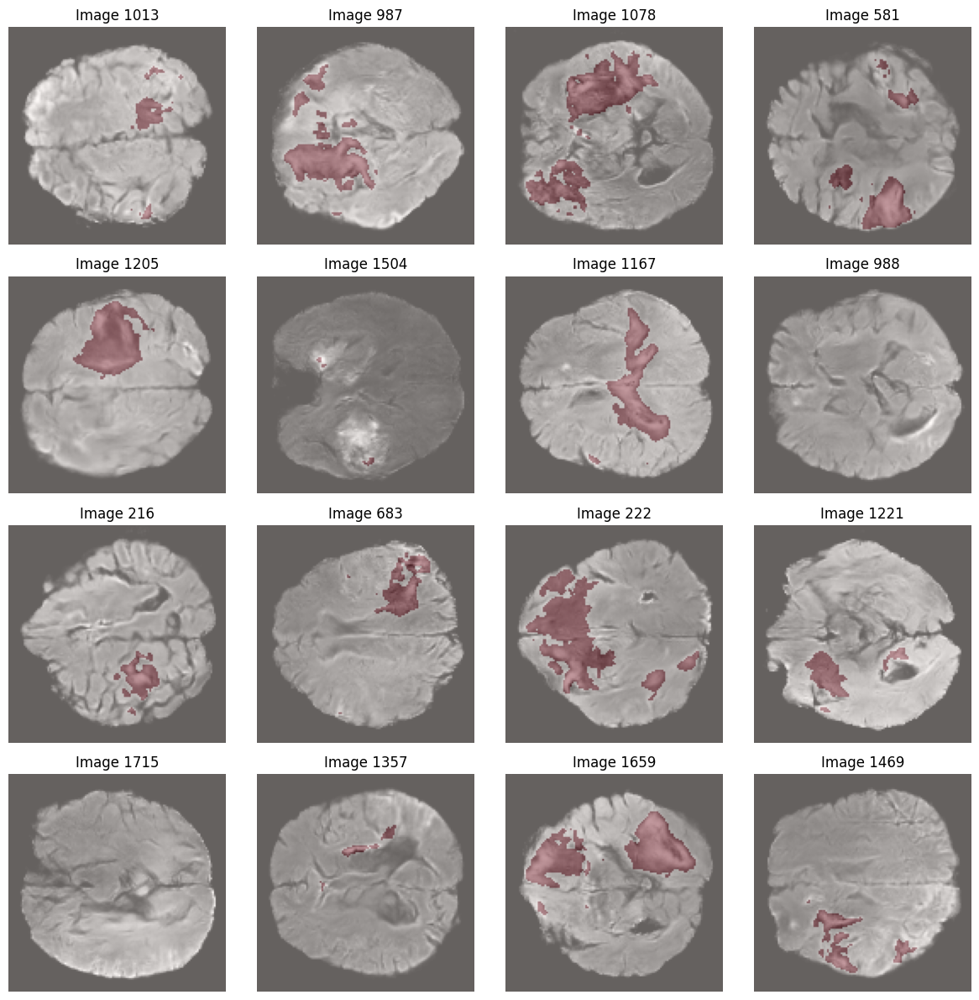

In [20]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = synthetic[idx].squeeze()
    mask = pseudo_masks[idx].squeeze()

    ax.imshow(img, cmap="gray")
    ax.imshow(mask, cmap="Reds", alpha=0.4)
    ax.set_title(f"Image {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

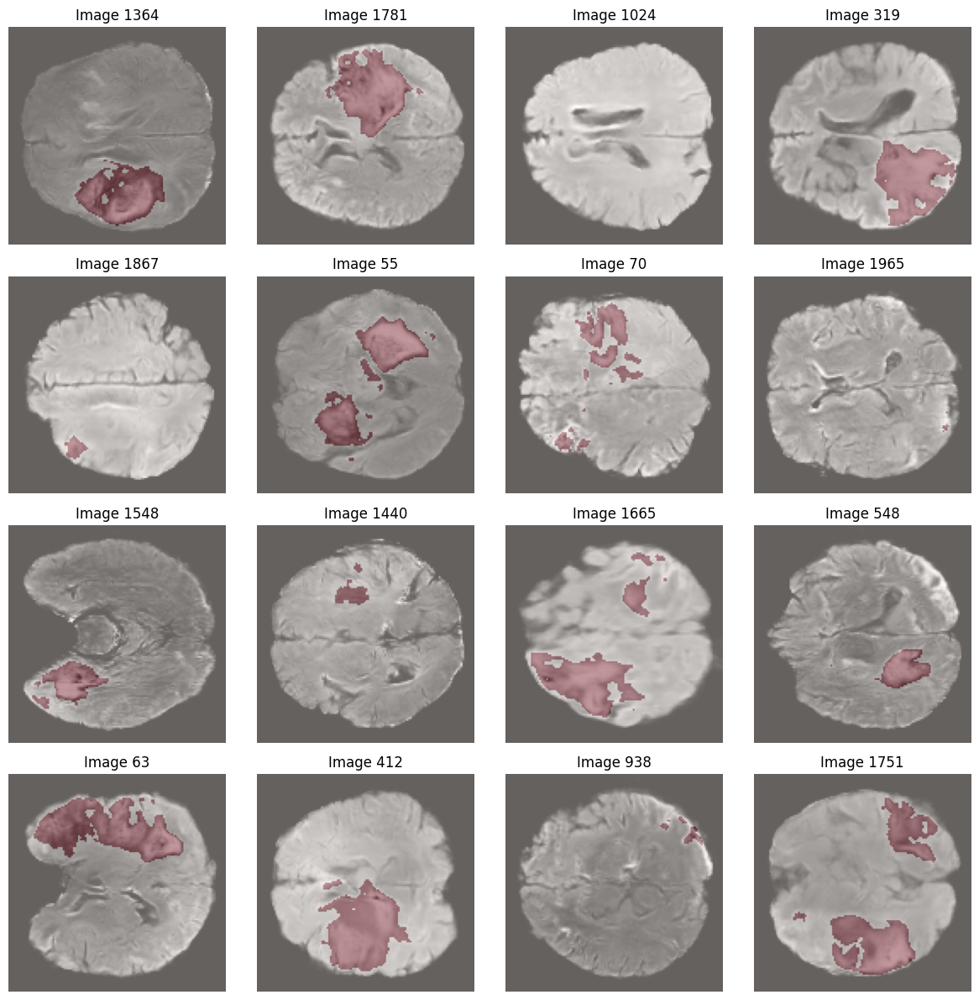

In [21]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = synthetic[idx].squeeze()
    mask = pseudo_masks[idx].squeeze()

    ax.imshow(img, cmap="gray")
    ax.imshow(mask, cmap="Reds", alpha=0.4)
    ax.set_title(f"Image {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

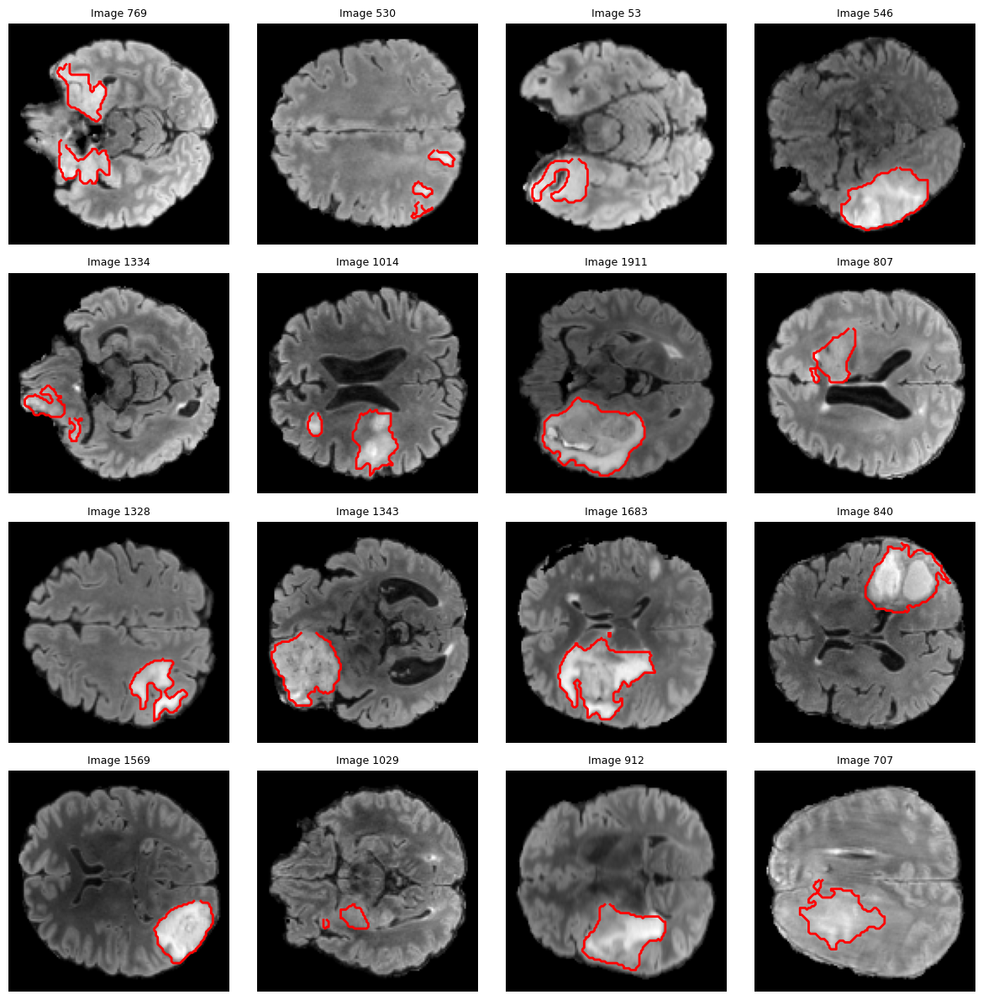

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = input_images[idx].squeeze()
    mask = input_masks[idx].squeeze().astype(np.uint8)

    ax.imshow(img, cmap='gray')

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours in red
    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color='red', linewidth=2)

    ax.set_title(f"Image {idx}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

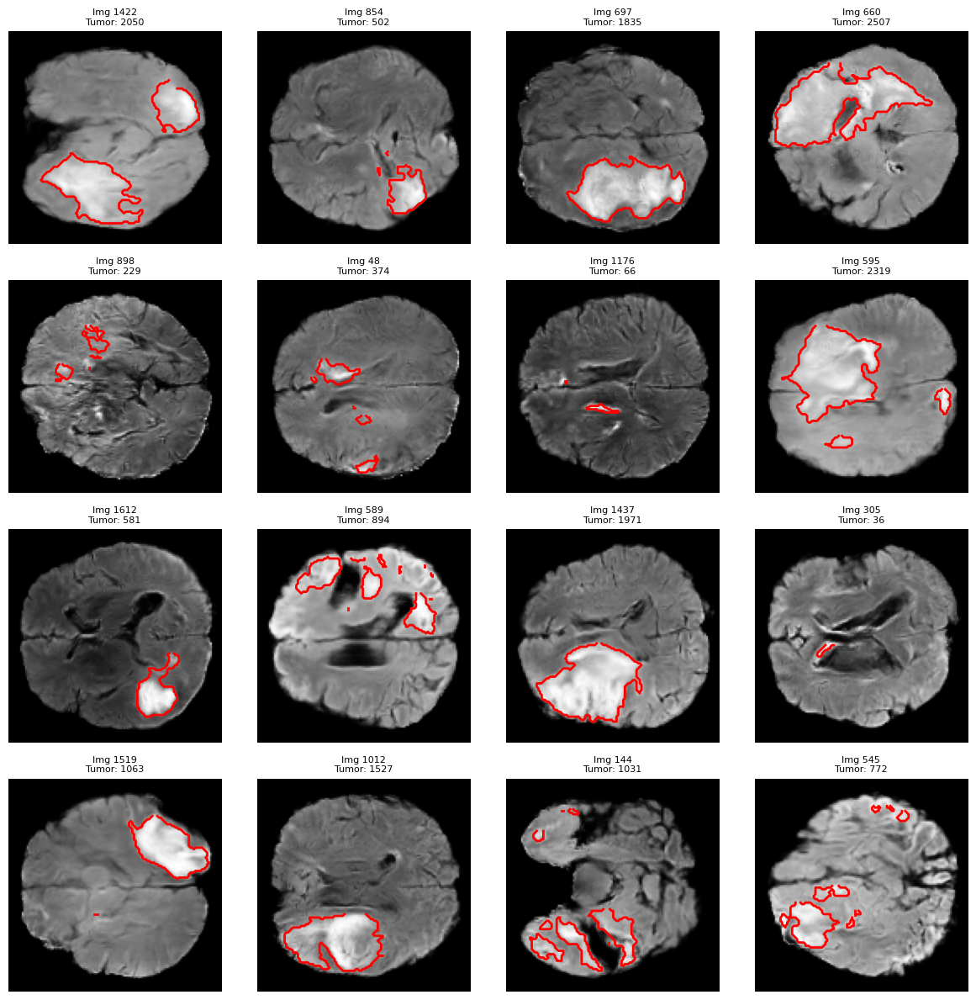

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Randomly choose 16 synthetic images
indices = np.random.choice(len(synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = synthetic[idx].squeeze()
    mask = pseudo_masks[idx].squeeze().astype(np.uint8)

    # Show synthetic MRI
    ax.imshow(img, cmap='gray')

    # Find tumor contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw contour
    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color='red', linewidth=2)

    tumor_pixels = int(mask.sum())

    ax.set_title(f"Img {idx}\nTumor: {tumor_pixels}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

# DCGAN

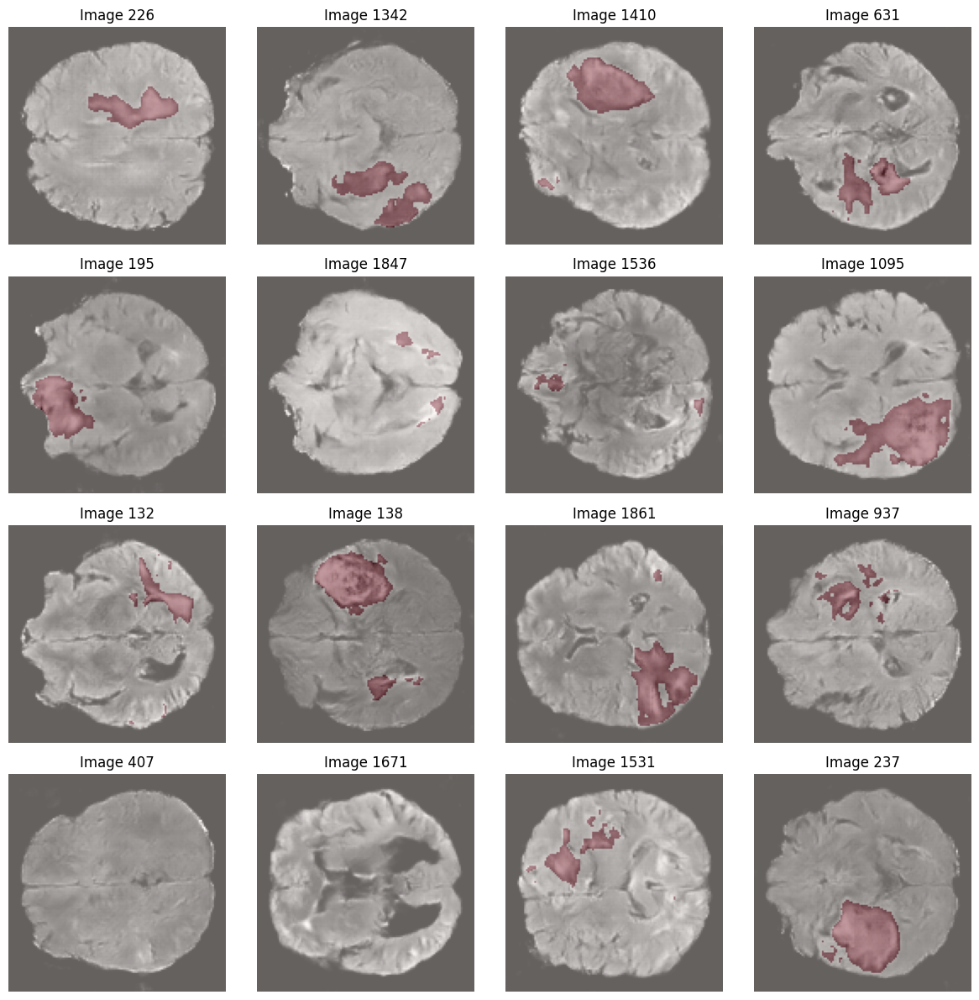

In [37]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(synthetic2), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = synthetic2[idx].squeeze()
    mask = DCGAN_masks[idx].squeeze()

    ax.imshow(img, cmap="gray")
    ax.imshow(mask, cmap="Reds", alpha=0.4)
    ax.set_title(f"Image {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

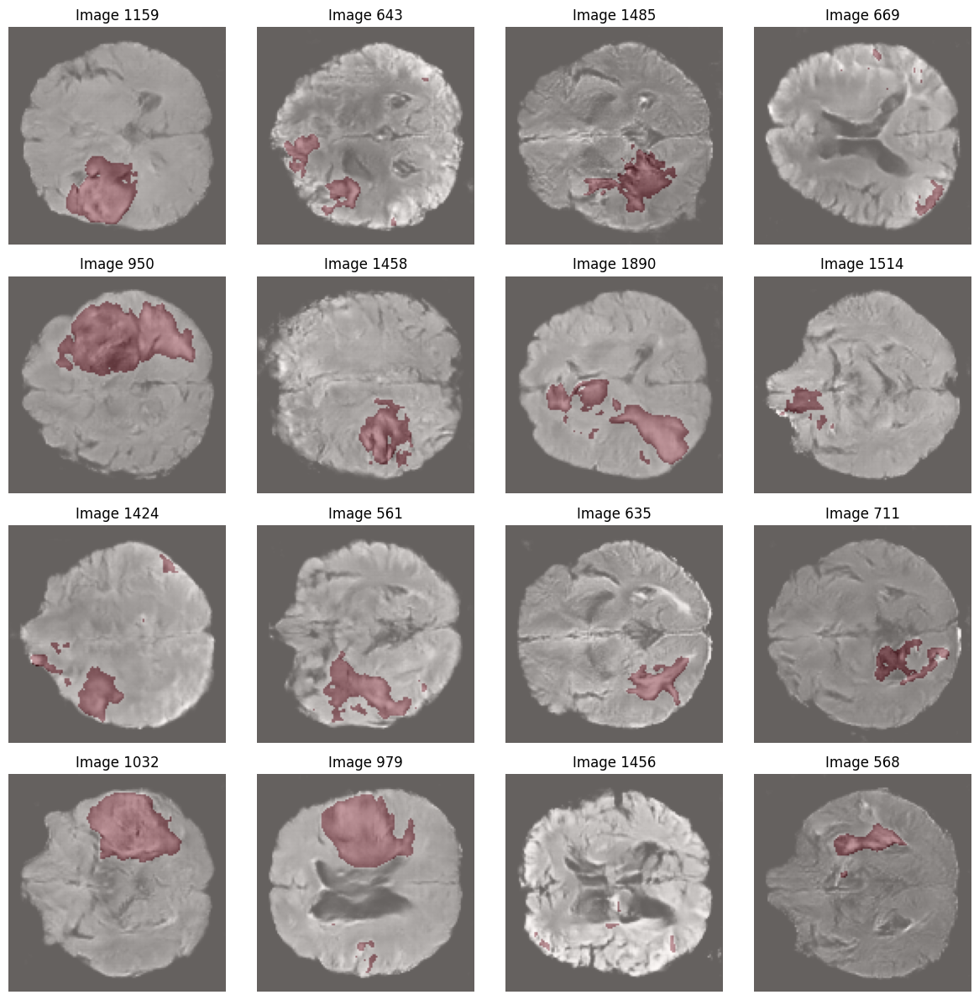

In [39]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(synthetic2), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = synthetic2[idx].squeeze()
    mask = DCGAN_masks[idx].squeeze()

    ax.imshow(img, cmap="gray")
    ax.imshow(mask, cmap="Reds", alpha=0.4)
    ax.set_title(f"Image {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

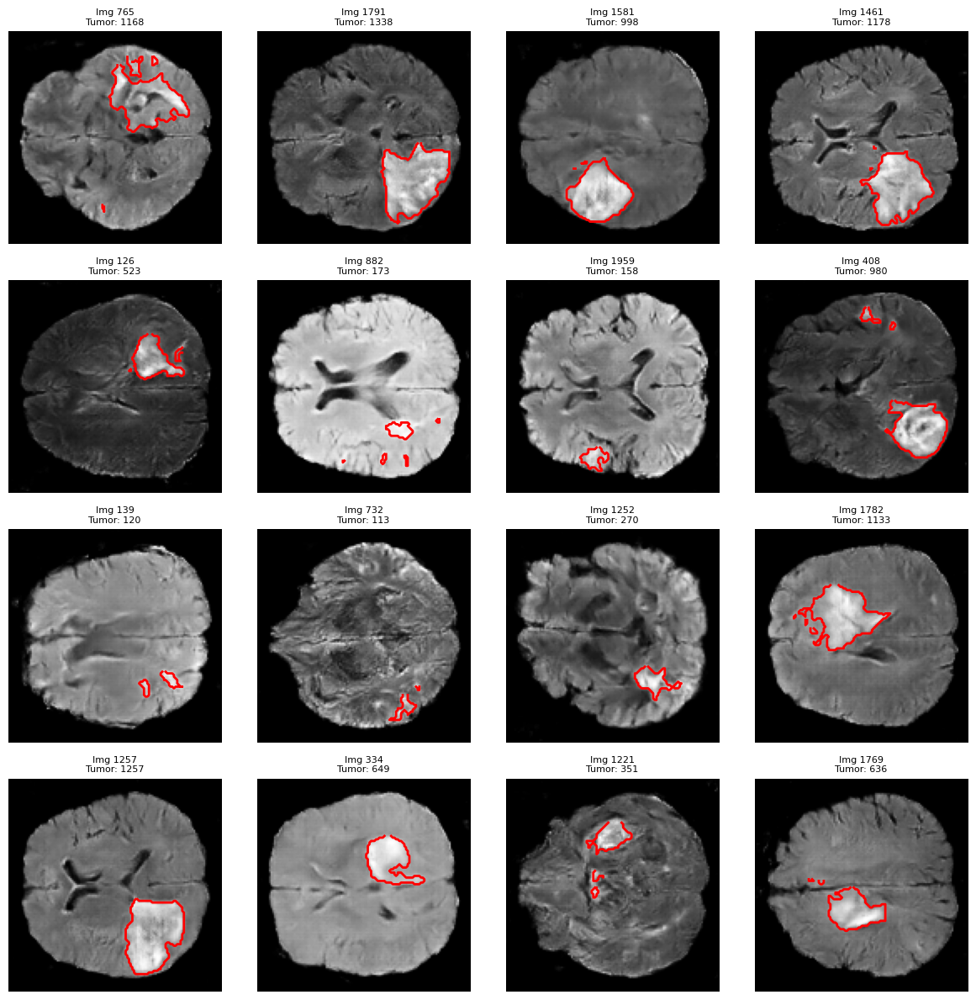

In [40]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Randomly choose 16 synthetic images
indices = np.random.choice(len(synthetic2), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = synthetic2[idx].squeeze()
    mask = DCGAN_masks[idx].squeeze().astype(np.uint8)

    # Show synthetic MRI
    ax.imshow(img, cmap='gray')

    # Find tumor contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw contour
    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color='red', linewidth=2)

    tumor_pixels = int(mask.sum())

    ax.set_title(f"Img {idx}\nTumor: {tumor_pixels}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

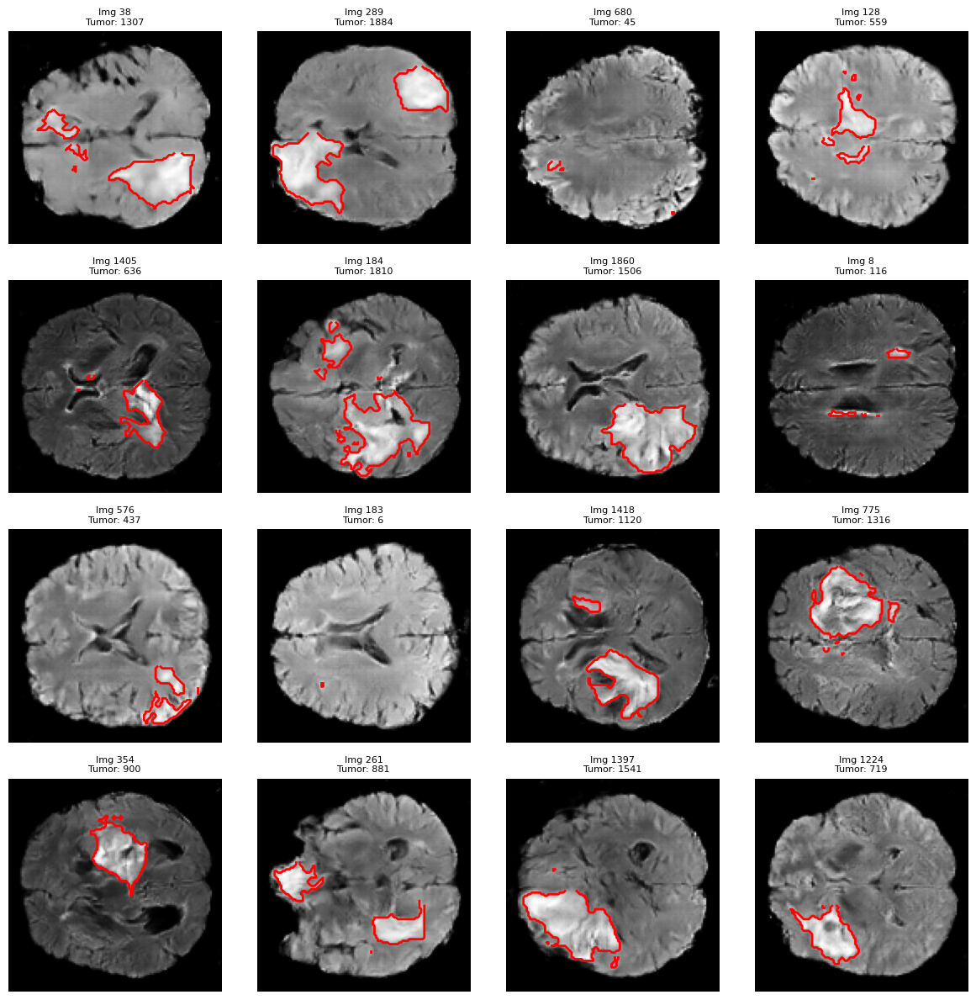

In [41]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Randomly choose 16 synthetic images
indices = np.random.choice(len(synthetic2), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = synthetic2[idx].squeeze()
    mask = DCGAN_masks[idx].squeeze().astype(np.uint8)

    # Show synthetic MRI
    ax.imshow(img, cmap='gray')

    # Find tumor contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw contour
    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color='red', linewidth=2)

    tumor_pixels = int(mask.sum())

    ax.set_title(f"Img {idx}\nTumor: {tumor_pixels}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

# WGAN

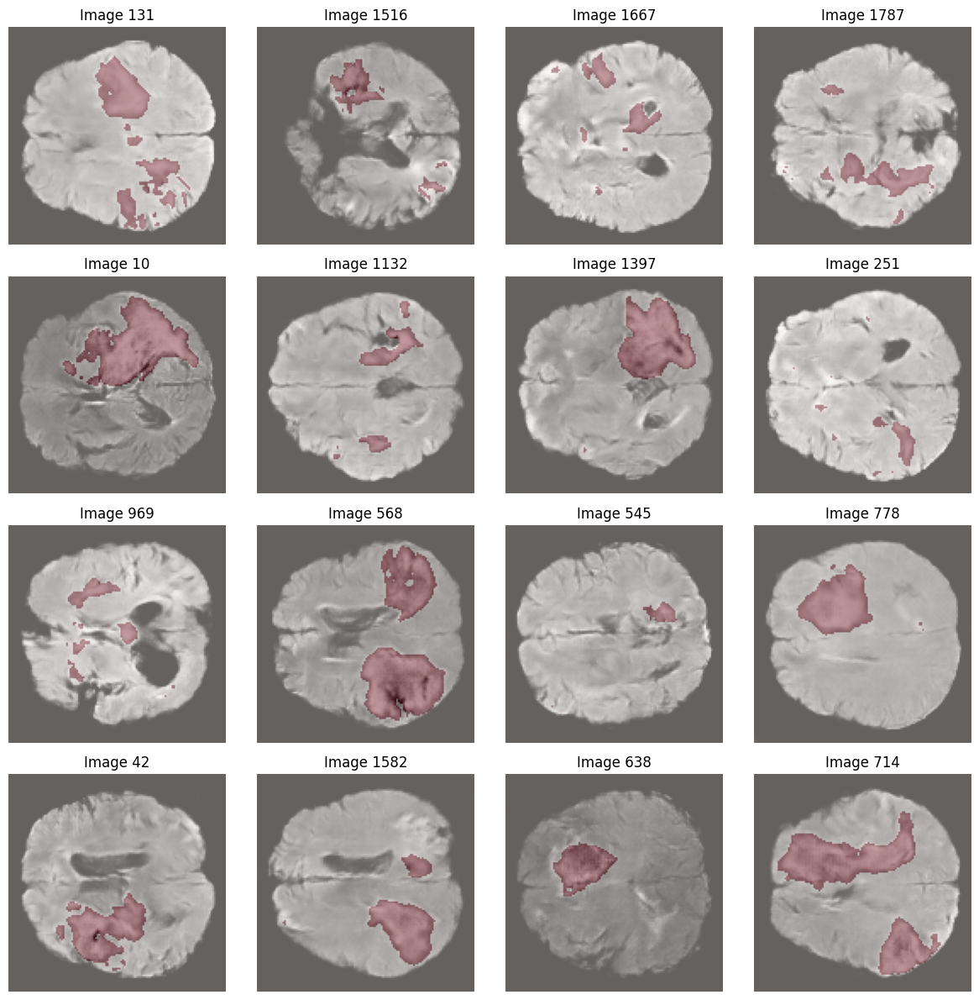

In [51]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(WGAN_synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = WGAN_synthetic[idx].squeeze()
    mask = WGAN_masks[idx].squeeze()

    ax.imshow(img, cmap="gray")
    ax.imshow(mask, cmap="Reds", alpha=0.4)
    ax.set_title(f"Image {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

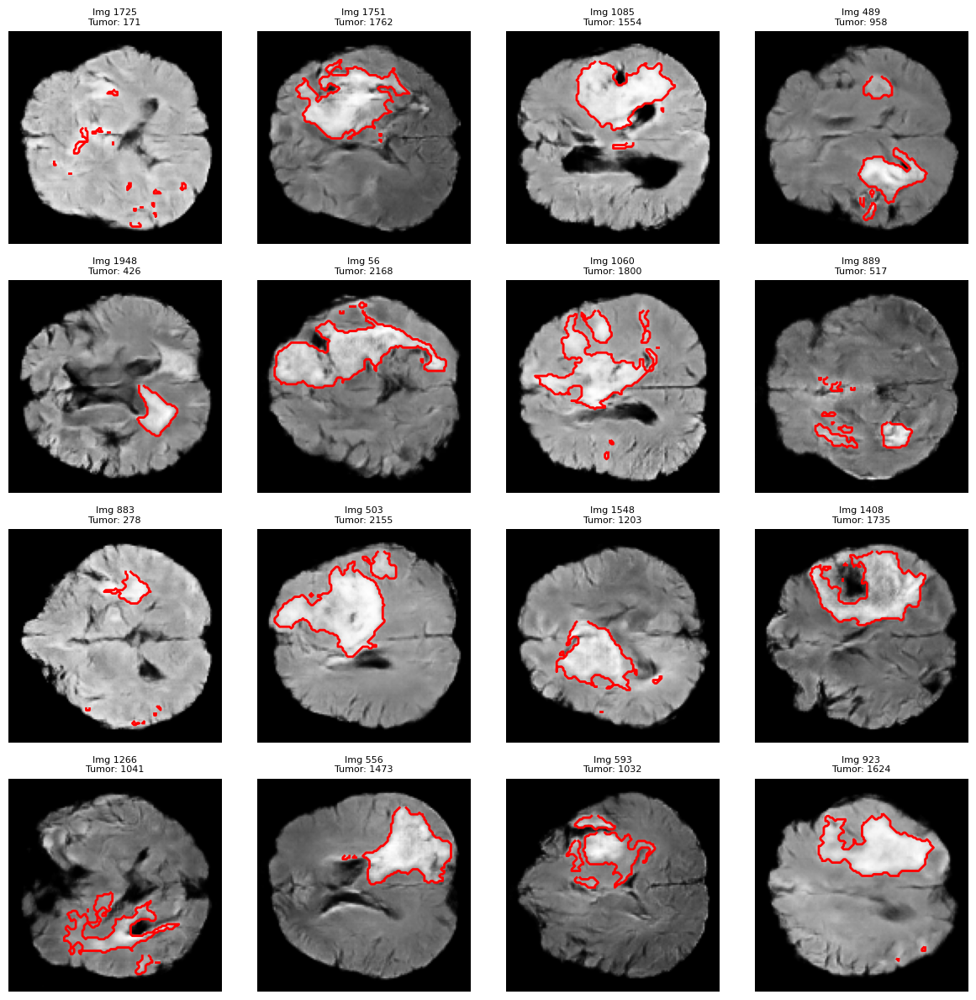

In [52]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Randomly choose 16 synthetic images
indices = np.random.choice(len(WGAN_synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = WGAN_synthetic[idx].squeeze()
    mask = WGAN_masks[idx].squeeze().astype(np.uint8)

    # Show synthetic MRI
    ax.imshow(img, cmap='gray')

    # Find tumor contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw contour
    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color='red', linewidth=2)

    tumor_pixels = int(mask.sum())

    ax.set_title(f"Img {idx}\nTumor: {tumor_pixels}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

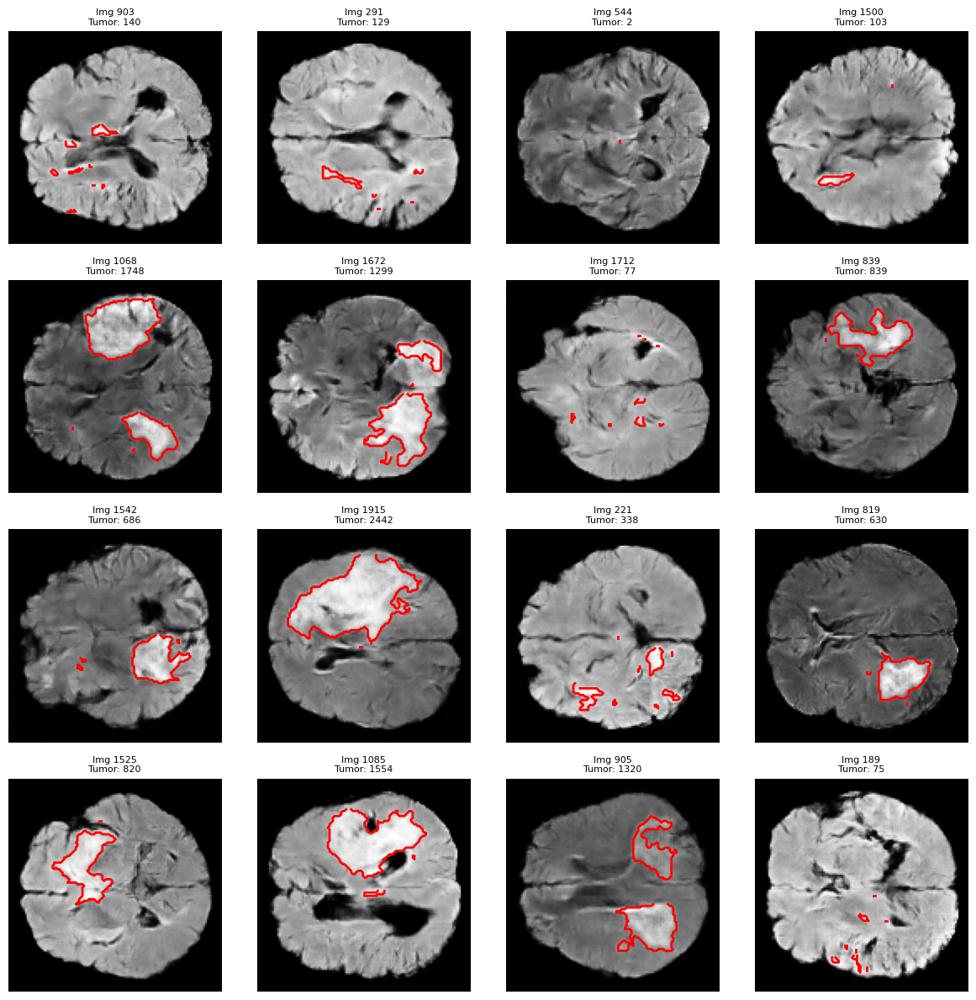

In [53]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Randomly choose 16 synthetic images
indices = np.random.choice(len(WGAN_synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = WGAN_synthetic[idx].squeeze()
    mask = WGAN_masks[idx].squeeze().astype(np.uint8)

    # Show synthetic MRI
    ax.imshow(img, cmap='gray')

    # Find tumor contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw contour
    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color='red', linewidth=2)

    tumor_pixels = int(mask.sum())

    ax.set_title(f"Img {idx}\nTumor: {tumor_pixels}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

#CGAN

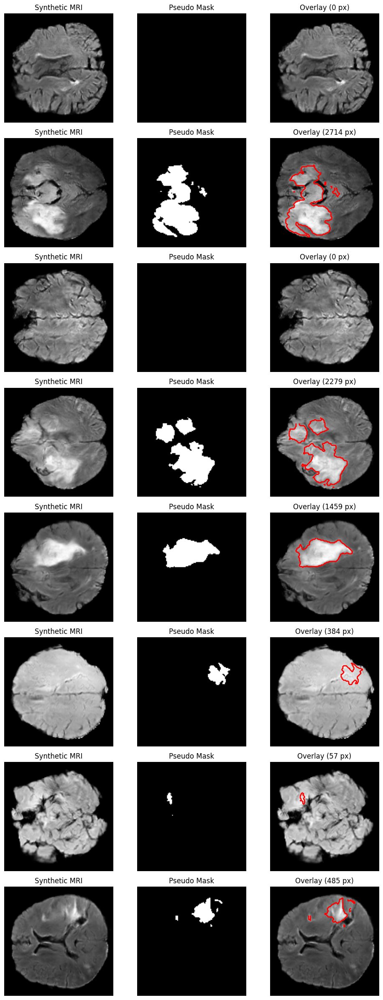

In [24]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Randomly select 8 synthetic images
indices = np.random.choice(len(synthetic), 8, replace=False)

fig, axes = plt.subplots(8, 3, figsize=(10, 24))

for row, idx in enumerate(indices):

    # Image
    img = synthetic[idx].squeeze()

    # If image is normalized to [-1,1], convert for display
    img_display = (img + 1) / 2
    img_display = np.clip(img_display, 0, 1)

    # Mask
    mask = pseudo_masks[idx].squeeze().astype(np.uint8)

    # --------------------------
    # Column 1 : Synthetic MRI
    # --------------------------
    axes[row,0].imshow(img_display, cmap='gray')
    axes[row,0].set_title("Synthetic MRI")
    axes[row,0].axis('off')

    # --------------------------
    # Column 2 : Pseudo Mask
    # --------------------------
    axes[row,1].imshow(mask, cmap='gray')
    axes[row,1].set_title("Pseudo Mask")
    axes[row,1].axis('off')

    # --------------------------
    # Column 3 : Overlay
    # --------------------------
    axes[row,2].imshow(img_display, cmap='gray')

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            axes[row,2].plot(cnt[:,0], cnt[:,1],
                             color='red',
                             linewidth=2)

    tumor_pixels = int(mask.sum())

    axes[row,2].set_title(f"Overlay ({tumor_pixels} px)")
    axes[row,2].axis('off')

plt.tight_layout()
plt.show()

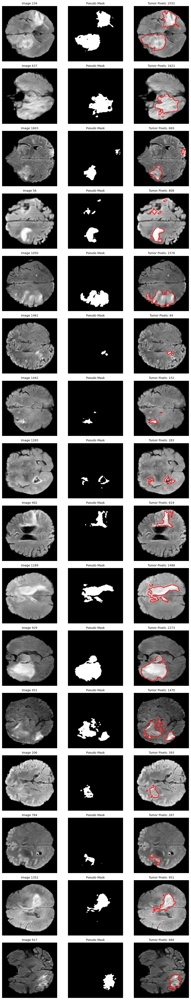

In [25]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Select 16 random synthetic images
indices = np.random.choice(len(synthetic), 16, replace=False)

fig, axes = plt.subplots(16, 3, figsize=(10, 48))

for row, idx in enumerate(indices):

    # Synthetic image
    img = synthetic[idx].squeeze()

    # If images are normalized to [-1,1], convert to [0,1] for display
    img_display = (img + 1) / 2
    img_display = np.clip(img_display, 0, 1)

    # Predicted mask
    mask = pseudo_masks[idx].squeeze().astype(np.uint8)

    # -----------------------
    # Column 1: Synthetic MRI
    # -----------------------
    axes[row, 0].imshow(img_display, cmap="gray")
    axes[row, 0].set_title(f"Image {idx}", fontsize=10)
    axes[row, 0].axis("off")

    # -----------------------
    # Column 2: Pseudo Mask
    # -----------------------
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Pseudo Mask", fontsize=10)
    axes[row, 1].axis("off")

    # -----------------------
    # Column 3: Overlay
    # -----------------------
    axes[row, 2].imshow(img_display, cmap="gray")

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            axes[row, 2].plot(
                cnt[:, 0],
                cnt[:, 1],
                color="red",
                linewidth=2
            )

    axes[row, 2].set_title(
        f"Tumor Pixels: {int(mask.sum())}",
        fontsize=10
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

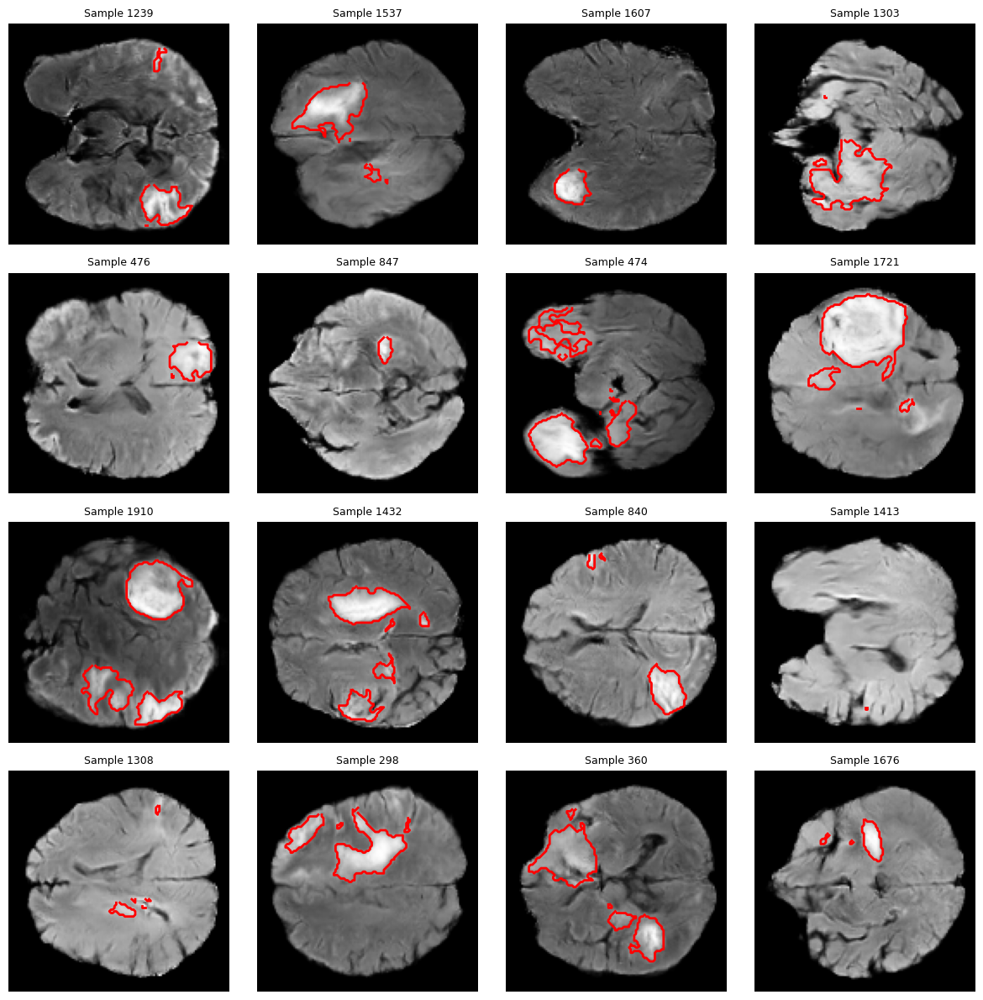

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

indices = np.random.choice(len(synthetic), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.ravel(), indices):

    img = (synthetic[idx].squeeze() + 1) / 2
    img = np.clip(img, 0, 1)

    mask = pseudo_masks[idx].squeeze().astype(np.uint8)

    ax.imshow(img, cmap="gray")

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        cnt = cnt.squeeze()
        if len(cnt.shape) == 2:
            ax.plot(cnt[:, 0], cnt[:, 1], color="red", linewidth=2)

    ax.set_title(f"Sample {idx}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
raw_predictions = model.predict(synthetic, batch_size=16)

print("Mean confidence:", raw_predictions.mean())
print("Max confidence :", raw_predictions.max())
print("Min confidence :", raw_predictions.min())

125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step
Mean confidence: 0.056408413
Max confidence : 1.0
Min confidence : 2.1126456e-07


In [28]:
print("Average predicted tumor pixels:", tumor_area.mean())

Average predicted tumor pixels: 3348.0


# CGAN

In [56]:
# Real tumor area distribution
real_tumor_area = input_masks.sum(axis=(1,2,3))

# Synthetic pseudo tumor area distribution
pseudo_tumor_area = pseudo_masks.sum(axis=(1,2,3))

print("===== Real BraTS Masks =====")
print(f"Mean tumor pixels : {real_tumor_area.mean():.2f}")
print(f"Median            : {np.median(real_tumor_area):.2f}")
print(f"Std               : {real_tumor_area.std():.2f}")
print(f"Min               : {real_tumor_area.min():.2f}")
print(f"Max               : {real_tumor_area.max():.2f}")


print("\n===== Synthetic Pseudo Masks =====")
print(f"Mean tumor pixels : {pseudo_tumor_area.mean():.2f}")
print(f"Median            : {np.median(pseudo_tumor_area):.2f}")
print(f"Std               : {pseudo_tumor_area.std():.2f}")
print(f"Min               : {pseudo_tumor_area.min():.2f}")
print(f"Max               : {pseudo_tumor_area.max():.2f}")

===== Real BraTS Masks =====
Mean tumor pixels : 1186.97
Median            : 1142.00
Std               : 647.34
Min               : 164.00
Max               : 3377.00

===== Synthetic Pseudo Masks =====
Mean tumor pixels : 923.52
Median            : 856.50
Std               : 665.81
Min               : 0.00
Max               : 3769.00


# DCGAN

In [54]:
# Real tumor area distribution
real_tumor_area = input_masks.sum(axis=(1,2,3))

# Synthetic pseudo tumor area distribution
pseudo_tumor_area = DCGAN_masks.sum(axis=(1,2,3))

print("===== Real BraTS Masks =====")
print(f"Mean tumor pixels : {real_tumor_area.mean():.2f}")
print(f"Median            : {np.median(real_tumor_area):.2f}")
print(f"Std               : {real_tumor_area.std():.2f}")
print(f"Min               : {real_tumor_area.min():.2f}")
print(f"Max               : {real_tumor_area.max():.2f}")


print("\n===== DCGAN Synthetic Pseudo Masks =====")
print(f"Mean tumor pixels : {pseudo_tumor_area.mean():.2f}")
print(f"Median            : {np.median(pseudo_tumor_area):.2f}")
print(f"Std               : {pseudo_tumor_area.std():.2f}")
print(f"Min               : {pseudo_tumor_area.min():.2f}")
print(f"Max               : {pseudo_tumor_area.max():.2f}")

===== Real BraTS Masks =====
Mean tumor pixels : 1186.97
Median            : 1142.00
Std               : 647.34
Min               : 164.00
Max               : 3377.00

===== DCGAN Synthetic Pseudo Masks =====
Mean tumor pixels : 816.41
Median            : 770.00
Std               : 547.45
Min               : 0.00
Max               : 3207.00


# WGAN

In [58]:
# Real tumor area distribution
real_tumor_area = input_masks.sum(axis=(1,2,3))

# Synthetic pseudo tumor area distribution
pseudo_tumor_area = WGAN_masks.sum(axis=(1,2,3))

print("===== Real BraTS Masks =====")
print(f"Mean tumor pixels : {real_tumor_area.mean():.2f}")
print(f"Median            : {np.median(real_tumor_area):.2f}")
print(f"Std               : {real_tumor_area.std():.2f}")
print(f"Min               : {real_tumor_area.min():.2f}")
print(f"Max               : {real_tumor_area.max():.2f}")


print("\n===== DCGAN Synthetic Pseudo Masks =====")
print(f"Mean tumor pixels : {pseudo_tumor_area.mean():.2f}")
print(f"Median            : {np.median(pseudo_tumor_area):.2f}")
print(f"Std               : {pseudo_tumor_area.std():.2f}")
print(f"Min               : {pseudo_tumor_area.min():.2f}")
print(f"Max               : {pseudo_tumor_area.max():.2f}")

===== Real BraTS Masks =====
Mean tumor pixels : 1186.97
Median            : 1142.00
Std               : 647.34
Min               : 164.00
Max               : 3377.00

===== DCGAN Synthetic Pseudo Masks =====
Mean tumor pixels : 1009.27
Median            : 952.00
Std               : 644.53
Min               : 0.00
Max               : 3132.00


# CGAN

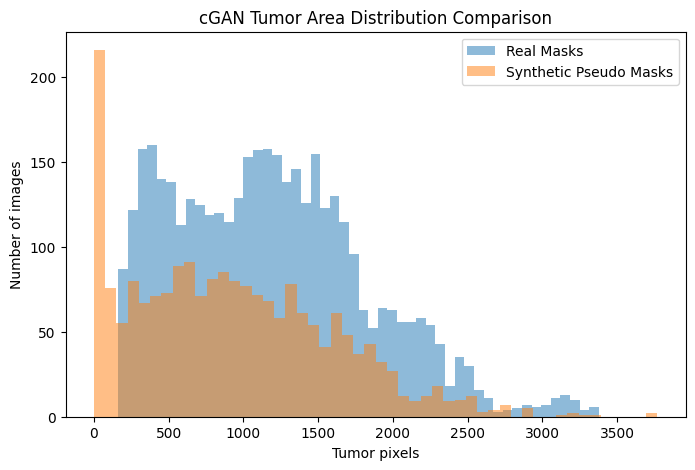

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(real_tumor_area, bins=50, alpha=0.5, label="Real Masks")
plt.hist(pseudo_tumor_area, bins=50, alpha=0.5, label="Synthetic Pseudo Masks")

plt.xlabel("Tumor pixels")
plt.ylabel("Number of images")
plt.title("cGAN Tumor Area Distribution Comparison")

plt.legend()
plt.show()

# DCGAN

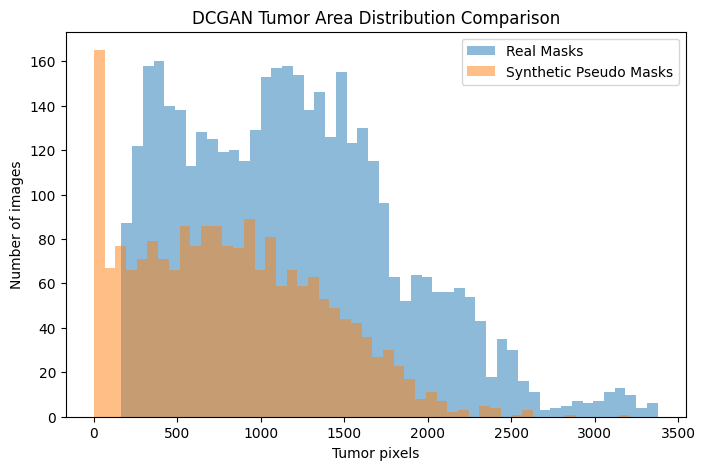

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(real_tumor_area, bins=50, alpha=0.5, label="Real Masks")
plt.hist(pseudo_tumor_area, bins=50, alpha=0.5, label="Synthetic Pseudo Masks")

plt.xlabel("Tumor pixels")
plt.ylabel("Number of images")
plt.title("DCGAN Tumor Area Distribution Comparison")

plt.legend()
plt.show()

# WGAN

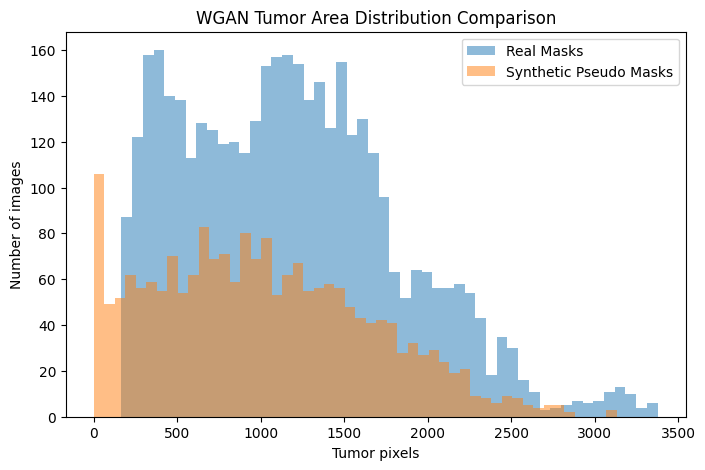

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(real_tumor_area, bins=50, alpha=0.5, label="Real Masks")
plt.hist(pseudo_tumor_area, bins=50, alpha=0.5, label="Synthetic Pseudo Masks")

plt.xlabel("Tumor pixels")
plt.ylabel("Number of images")
plt.title("WGAN Tumor Area Distribution Comparison")

plt.legend()
plt.show()

# Step 5: Load Synthetic Images + Pseudo Masks

In [16]:
synthetic = np.load(
    "/kaggle/input/datasets/shantaakterid170/generated-cgan/generated_images_128 (8).npy"
)

pseudo_masks = np.load(
    "/kaggle/input/datasets/shantaakterid170/synthetic-mask/synthetic_masks.npy"
)

print(synthetic.shape)
print(pseudo_masks.shape)

(2000, 128, 128, 1)
(2000, 128, 128, 1)


# DCGAN

In [11]:
synthetic = np.load(
    "/kaggle/input/datasets/shantaakterid170/pseudo-mask/DCGAN_synthetic_for_mask.npy"
)

pseudo_masks = np.load(
    "/kaggle/input/datasets/shantaakterid170/pseudo-mask/DCGAN_masks.npy"
)

print(synthetic.shape)
print(pseudo_masks.shape)

(2000, 128, 128, 1)
(2000, 128, 128, 1)


# WGAN

In [16]:
synthetic = np.load(
    "/kaggle/input/datasets/shantaakterid170/wgan-best/WGANgenerated_images7.npy"
)

pseudo_masks = np.load(
    "/kaggle/input/datasets/shantaakterid170/pseudo-mask/WGAN_masks.npy"
)

print(synthetic.shape)
print(pseudo_masks.shape)

(2000, 128, 128, 1)
(2000, 128, 128, 1)


In [22]:
print(f"Min: {synthetic.min():.4f}")
print(f"Max: {synthetic.max():.4f}")

if synthetic.min() >= -1 and synthetic.max() <= 1:
    print("✅ Images are normalized to [-1, 1].")
else:
    print("❌ Images are NOT in the range [-1, 1].")

Min: -1.0000
Max: 0.9955
✅ Images are normalized to [-1, 1].


In [21]:
synthetic = synthetic * 2 - 1

In [23]:
from sklearn.utils import shuffle

X_aug = np.concatenate(
    [X_real10, synthetic],
    axis=0
)

Y_aug = np.concatenate(
    [Y_real10, pseudo_masks],
    axis=0
)

X_aug, Y_aug = shuffle(
    X_aug,
    Y_aug,
    random_state=42
)

print(X_aug.shape)

(2320, 128, 128, 1)


In [24]:
aug_model = build_unet()

aug_model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        tf.keras.metrics.BinaryIoU(
            target_class_ids=[1]
        )
    ]
)

history_aug = aug_model.fit(
    X_aug,
    Y_aug,

    validation_data=(
        X_val,
        Y_val
    ),

    epochs=50,
    batch_size=16,

    callbacks=callbacks
)

Epoch 1/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 69s 344ms/step - binary_io_u_2: 0.5149 - dice_coef: 0.5655 - loss: 0.6011 - val_binary_io_u_2: 0.0723 - val_dice_coef: 0.1348 - val_loss: 90.8363
Epoch 2/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 45s 310ms/step - binary_io_u_2: 0.7477 - dice_coef: 0.8271 - loss: 0.2324 - val_binary_io_u_2: 0.1006 - val_dice_coef: 0.1819 - val_loss: 10.7879
Epoch 3/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 46s 316ms/step - binary_io_u_2: 0.7804 - dice_coef: 0.8571 - loss: 0.1919 - val_binary_io_u_2: 0.3096 - val_dice_coef: 0.4671 - val_loss: 1.4342
Epoch 4/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 45s 313ms/step - binary_io_u_2: 0.7911 - dice_coef: 0.8680 - loss: 0.1788 - val_binary_io_u_2: 0.5522 - val_dice_coef: 0.7058 - val_loss: 0.5290
Epoch 5/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 46s 315ms/step - binary_io_u_2: 0.8093 - dice_coef: 0.8801 - loss: 0.1618 - val_binary_io_u_2: 0.7782 - val_dice_coef: 0.8687 - val_loss: 0.2099
Epoch 6/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 45s 313ms/step - binary_io_u_2: 0

# Step 8: Evaluate Augmented Model

# cGAN

In [19]:
aug_results = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("===== Augmented U-Net =====")
print(f"Loss : {aug_results[0]:.4f}")
print(f"Dice : {aug_results[1]:.4f}")
print(f"IoU  : {aug_results[2]:.4f}")

===== Augmented U-Net =====
Loss : 0.1024
Dice : 0.9338
IoU  : 0.8824


# DCGAN

In [63]:
aug_results = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("===== Augmented U-Net =====")
print(f"Loss : {aug_results[0]:.4f}")
print(f"Dice : {aug_results[1]:.4f}")
print(f"IoU  : {aug_results[2]:.4f}")

===== Augmented U-Net =====
Loss : 0.1013
Dice : 0.9361
IoU  : 0.8857


# 2nd train

In [14]:
aug_results = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("===== Augmented U-Net =====")
print(f"Loss : {aug_results[0]:.4f}")
print(f"Dice : {aug_results[1]:.4f}")
print(f"IoU  : {aug_results[2]:.4f}")

===== Augmented U-Net =====
Loss : 0.1044
Dice : 0.9340
IoU  : 0.8824


# WGAN

In [25]:
aug_results = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("===== Augmented U-Net =====")
print(f"Loss : {aug_results[0]:.4f}")
print(f"Dice : {aug_results[1]:.4f}")
print(f"IoU  : {aug_results[2]:.4f}")

===== Augmented U-Net =====
Loss : 0.1017
Dice : 0.9359
IoU  : 0.8852


# Step 9: Final Comparison Table

In [20]:
import pandas as pd

comparison = pd.DataFrame({

    "Training Data":[
        "320 Real",
        "320 Real + 2000 Synthetic"
    ],

    "Loss":[
        baseline_results[0],
        aug_results[0]
    ],

    "Dice":[
        baseline_results[1],
        aug_results[1]
    ],

    "IoU":[
        baseline_results[2],
        aug_results[2]
    ]
})

comparison

,Training Data,Loss,Dice,IoU
0,320 Real,0.135789,0.910121,0.845996
1,320 Real + 2000 Synthetic,0.102431,0.933768,0.882391


In [15]:
import pandas as pd

comparison = pd.DataFrame({

    "Training Data":[
        "320 Real",
        "320 Real + DCGAN 2000 Synthetic"
    ],

    "Loss":[
        baseline_results[0],
        aug_results[0]
    ],

    "Dice":[
        baseline_results[1],
        aug_results[1]
    ],

    "IoU":[
        baseline_results[2],
        aug_results[2]
    ]
})

comparison

NameError: name 'baseline_results' is not defined

# 3200+2000 synthetic

In [33]:
synthetic.shape
# (2000,128,128,1)

(2000, 128, 128, 1)

In [34]:
pseudo_masks.shape
# (2000,128,128,1)

(2000, 128, 128, 1)

In [43]:
X_augmented = np.concatenate(
    [X_train, synthetic[:1000]],
    axis=0
)

Y_augmented = np.concatenate(
    [Y_train, pseudo_masks[:1000]],
    axis=0
)


print("Augmented images:", X_augmented.shape)
print("Augmented masks :", Y_augmented.shape)

Augmented images: (4200, 128, 128, 1)
Augmented masks : (4200, 128, 128, 1)


In [44]:
from sklearn.utils import shuffle

X_augmented, Y_augmented = shuffle(
    X_augmented,
    Y_augmented,
    random_state=42
)

In [45]:
aug_model = build_unet(
    input_shape=(128,128,1)
)

In [46]:
aug_model.compile(
    optimizer=Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        tf.keras.metrics.BinaryIoU(target_class_ids=[1])
    ]
)

In [39]:
history_aug = aug_model.fit(

    X_augmented,
    Y_augmented,

    validation_data=(
        X_test,
        Y_test
    ),

    epochs=50,

    batch_size=16,

    callbacks=callbacks
)

Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 116s 280ms/step - binary_io_u_1: 0.4837 - dice_coef: 0.4434 - loss: 0.8368 - val_binary_io_u_1: 0.7164 - val_dice_coef: 0.5491 - val_loss: 0.5640
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 88s 270ms/step - binary_io_u_1: 0.8185 - dice_coef: 0.6934 - loss: 0.3798 - val_binary_io_u_1: 0.8027 - val_dice_coef: 0.7550 - val_loss: 0.3315
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 87s 269ms/step - binary_io_u_1: 0.8394 - dice_coef: 0.7816 - loss: 0.2705 - val_binary_io_u_1: 0.8294 - val_dice_coef: 0.8348 - val_loss: 0.2261
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 88s 272ms/step - binary_io_u_1: 0.8554 - dice_coef: 0.8388 - loss: 0.2024 - val_binary_io_u_1: 0.8733 - val_dice_coef: 0.8745 - val_loss: 0.1617
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 88s 270ms/step - binary_io_u_1: 0.8646 - dice_coef: 0.8712 - loss: 0.1645 - val_binary_io_u_1: 0.8359 - val_dice_coef: 0.8703 - val_loss: 0.1743
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 88s 270ms/step - binary_io_u_1: 0.

# for 1000 synthetic

In [47]:
history_aug = aug_model.fit(

    X_augmented,
    Y_augmented,

    validation_data=(
        X_test,
        Y_test
    ),

    epochs=50,

    batch_size=16,

    callbacks=callbacks
)

Epoch 1/50
262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - binary_io_u_2: 0.6391 - dice_coef: 0.5446 - loss: 0.6137

2026-07-09 21:07:49.714595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 21:07:50.038838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 21:07:51.180123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 21:07:51.547823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 21:07:52.079319: E external/local_xla/xla/stream_

263/263 ━━━━━━━━━━━━━━━━━━━━ 138s 428ms/step - binary_io_u_2: 0.6399 - dice_coef: 0.5455 - loss: 0.6124 - val_binary_io_u_2: 0.6135 - val_dice_coef: 0.5929 - val_loss: 0.5032
Epoch 2/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 73s 279ms/step - binary_io_u_2: 0.8287 - dice_coef: 0.7862 - loss: 0.2673 - val_binary_io_u_2: 0.7294 - val_dice_coef: 0.7736 - val_loss: 0.3271
Epoch 3/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 73s 276ms/step - binary_io_u_2: 0.8498 - dice_coef: 0.8434 - loss: 0.1976 - val_binary_io_u_2: 0.8641 - val_dice_coef: 0.8798 - val_loss: 0.1609
Epoch 4/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 72s 274ms/step - binary_io_u_2: 0.8654 - dice_coef: 0.8772 - loss: 0.1573 - val_binary_io_u_2: 0.8856 - val_dice_coef: 0.9035 - val_loss: 0.1271
Epoch 5/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 73s 276ms/step - binary_io_u_2: 0.8743 - dice_coef: 0.8961 - loss: 0.1348 - val_binary_io_u_2: 0.8926 - val_dice_coef: 0.9184 - val_loss: 0.1093
Epoch 6/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 73s 277ms/step - binary_io_u_2: 0.8852 - dice

In [40]:
results_aug = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)


for name,value in zip(
    aug_model.metrics_names,
    results_aug
):
    print(f"{name}: {value:.4f}")

loss: 0.0541
compile_metrics: 0.9663


In [41]:
baseline_results = model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

augmented_results = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)


import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Baseline U-Net",
        "Synthetic Augmented U-Net"
    ],

    "Dice":[
        baseline_results[1],
        augmented_results[1]
    ],

    "IoU":[
        baseline_results[2],
        augmented_results[2]
    ]

})


comparison

,Model,Dice,IoU
0,Baseline U-Net,0.967128,0.939216
1,Synthetic Augmented U-Net,0.966295,0.937322


In [42]:
import pandas as pd

# Evaluate baseline U-Net
baseline_results = model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

# Evaluate augmented U-Net
augmented_results = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)


# Create comparison table
comparison = pd.DataFrame({

    "Model": [
        "Baseline U-Net",
        "Synthetic Augmented U-Net"
    ],

    "Loss": [
        baseline_results[0],
        augmented_results[0]
    ],

    "Dice Coefficient": [
        baseline_results[1],
        augmented_results[1]
    ],

    "IoU": [
        baseline_results[2],
        augmented_results[2]
    ]

})


# Display with 4 decimal places
comparison.style.format({
    "Loss": "{:.4f}",
    "Dice Coefficient": "{:.4f}",
    "IoU": "{:.4f}"
})

,Model,Loss,Dice Coefficient,IoU
0,Baseline U-Net,0.0529,0.9671,0.9392
1,Synthetic Augmented U-Net,0.0541,0.9663,0.9373


# 1000 synthetic

In [48]:
import pandas as pd

# Evaluate baseline U-Net
baseline_results = model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

# Evaluate augmented U-Net
augmented_results = aug_model.evaluate(
    X_test,
    Y_test,
    verbose=0
)


# Create comparison table
comparison = pd.DataFrame({

    "Model": [
        "Baseline U-Net",
        "Synthetic Augmented U-Net"
    ],

    "Loss": [
        baseline_results[0],
        augmented_results[0]
    ],

    "Dice Coefficient": [
        baseline_results[1],
        augmented_results[1]
    ],

    "IoU": [
        baseline_results[2],
        augmented_results[2]
    ]

})


# Display with 4 decimal places
comparison.style.format({
    "Loss": "{:.4f}",
    "Dice Coefficient": "{:.4f}",
    "IoU": "{:.4f}"
})

,Model,Loss,Dice Coefficient,IoU
0,Baseline U-Net,0.0529,0.9671,0.9392
1,Synthetic Augmented U-Net,0.0543,0.9668,0.9381


In [30]:
from scipy.stats import f_oneway

dcgan_fid = [89.59,84.71,60.49]
cgan_fid  = [34.06,34.06,52.54]
wgan_fid  = [90.35,97.30,76.26]

F,p = f_oneway(dcgan_fid,cgan_fid,wgan_fid)

print("FID ANOVA")
print("F =",F)
print("p =",p)

FID ANOVA
F = 12.154431225368523
p = 0.007757911854362654


In [31]:
dcgan_is = [2.3527,2.2643,2.1287]
cgan_is  = [2.2573,2.2573,2.1629]
wgan_is  = [2.0636,2.1064,2.1967]

F,p = f_oneway(dcgan_is,cgan_is,wgan_is)

print("IS ANOVA")
print("F =",F)
print("p =",p)

IS ANOVA
F = 2.008896641553087
p = 0.2148510862670079


In [32]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

scores = dcgan_fid + cgan_fid + wgan_fid

models = (["DCGAN"]*3 +
          ["cGAN"]*3 +
          ["WGAN-GP"]*3)

df = pd.DataFrame({
    "FID":scores,
    "Model":models
})

tukey = pairwise_tukeyhsd(
    endog=df["FID"],
    groups=df["Model"],
    alpha=0.05
)

print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2 meandiff p-adj   lower    upper   reject
--------------------------------------------------------
  DCGAN WGAN-GP   9.7067 0.6327 -21.7048  41.1181  False
  DCGAN    cGAN -38.0433 0.0231 -69.4548  -6.6319   True
WGAN-GP    cGAN   -47.75 0.0082 -79.1614 -16.3386   True
--------------------------------------------------------


In [33]:
scores = dcgan_is + cgan_is + wgan_is

df = pd.DataFrame({
    "IS":scores,
    "Model":models
})

tukey = pairwise_tukeyhsd(
    endog=df["IS"],
    groups=df["Model"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
  DCGAN WGAN-GP  -0.1263 0.2243 -0.3325 0.0798  False
  DCGAN    cGAN  -0.0227 0.9395 -0.2289 0.1834  False
WGAN-GP    cGAN   0.1036 0.3385 -0.1026 0.3098  False
-----------------------------------------------------


/tmp/ipykernel_57/2529387079.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


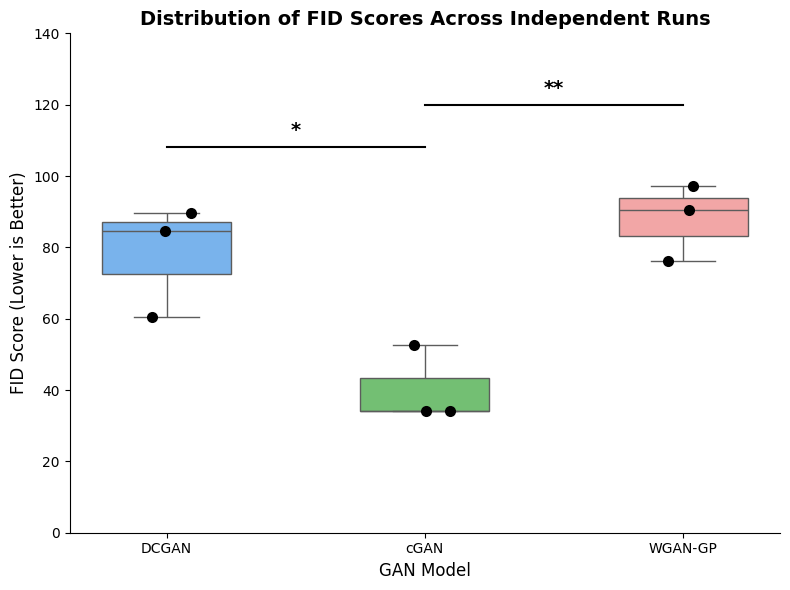

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Data
data = pd.DataFrame({
    "Model": (
        ["DCGAN"]*3 +
        ["cGAN"]*3 +
        ["WGAN-GP"]*3
    ),
    "FID": [
        89.59,84.71,60.49,
        34.06,34.06,52.54,
        90.35,97.30,76.26
    ]
})


plt.figure(figsize=(8,6))

palette = {
    "DCGAN":"#66b3ff",
    "cGAN":"#66cc66",
    "WGAN-GP":"#ff9999"
}


ax = sns.boxplot(
    data=data,
    x="Model",
    y="FID",
    palette=palette,
    width=0.5
)


sns.stripplot(
    data=data,
    x="Model",
    y="FID",
    color="black",
    size=8,
    jitter=True
)


# ==============================
# Significance markers
# ==============================

def add_significance(x1, x2, y, text):

    ax.plot(
        [x1, x2],
        [y, y],
        linewidth=1.5,
        color="black"
    )

    ax.text(
        (x1+x2)/2,
        y+2,
        text,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )


# DCGAN vs cGAN
add_significance(
    0,
    1,
    108,
    "*"
)


# cGAN vs WGAN-GP
add_significance(
    1,
    2,
    120,
    "**"
)


# Formatting
plt.ylabel(
    "FID Score (Lower is Better)",
    fontsize=12
)

plt.xlabel(
    "GAN Model",
    fontsize=12
)

plt.title(
    "Distribution of FID Scores Across Independent Runs",
    fontsize=14,
    fontweight="bold"
)


plt.ylim(0,140)


# cleaner look
sns.despine()

plt.grid(
    axis="y",
    linestyle="",
    alpha=0.3
)


plt.tight_layout()

plt.show()

/tmp/ipykernel_57/501029628.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


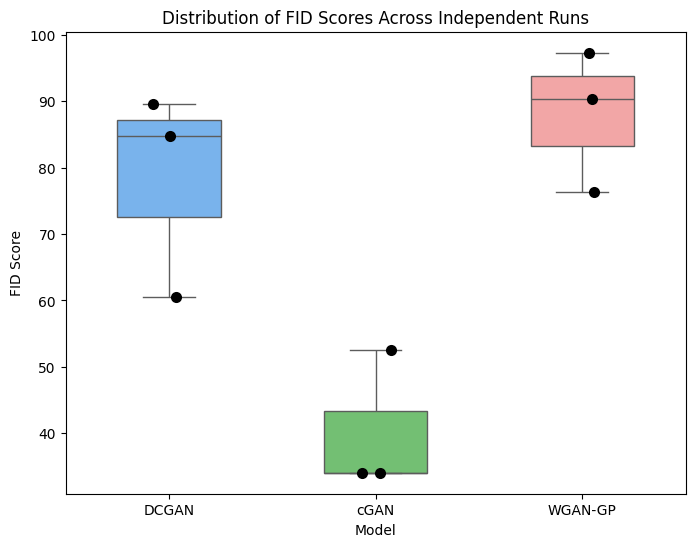

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data
data = pd.DataFrame({
    "Model": (
        ["DCGAN"]*3 +
        ["cGAN"]*3 +
        ["WGAN-GP"]*3
    ),
    "FID": [
        89.59,84.71,60.49,
        34.06,34.06,52.54,
        90.35,97.30,76.26
    ]
})

plt.figure(figsize=(8,6))

palette = {
    "DCGAN":"#66b3ff",
    "cGAN":"#66cc66",
    "WGAN-GP":"#ff9999"
}

sns.boxplot(
    data=data,
    x="Model",
    y="FID",
    palette=palette,
    width=0.5
)

sns.stripplot(
    data=data,
    x="Model",
    y="FID",
    color="black",
    size=8,
    jitter=True
)

plt.ylabel("FID Score")
plt.title("Distribution of FID Scores Across Independent Runs")

plt.show()

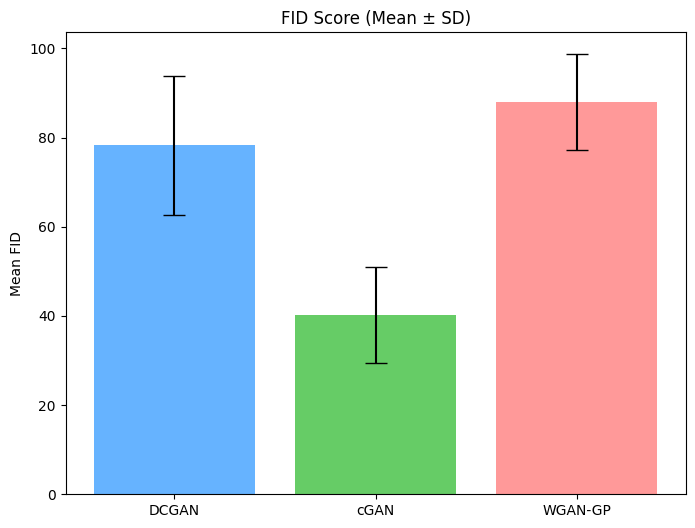

In [35]:
import numpy as np

means = [
    np.mean([89.59,84.71,60.49]),
    np.mean([34.06,34.06,52.54]),
    np.mean([90.35,97.30,76.26])
]

stds = [
    np.std([89.59,84.71,60.49],ddof=1),
    np.std([34.06,34.06,52.54],ddof=1),
    np.std([90.35,97.30,76.26],ddof=1)
]

models=["DCGAN","cGAN","WGAN-GP"]

plt.figure(figsize=(8,6))

colors=["#66b3ff","#66cc66","#ff9999"]

plt.bar(
    models,
    means,
    yerr=stds,
    capsize=8,
    color=colors
)

plt.ylabel("Mean FID")

plt.title("FID Score (Mean ± SD)")

plt.show()

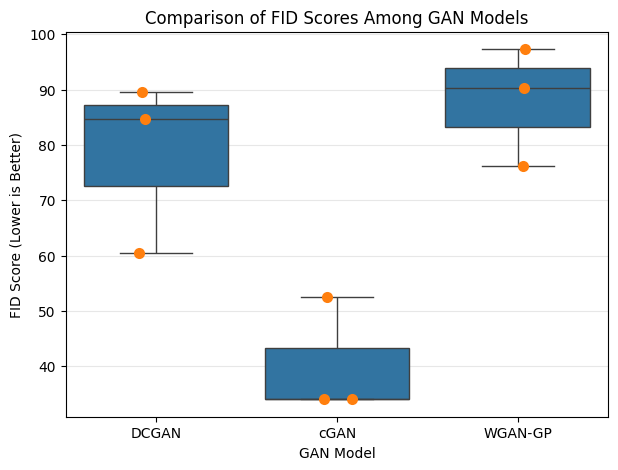

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = pd.DataFrame({
    "FID": dcgan_fid + cgan_fid + wgan_fid,
    "Model": (
        ["DCGAN"]*3 +
        ["cGAN"]*3 +
        ["WGAN-GP"]*3
    )
})


plt.figure(figsize=(7,5))

sns.boxplot(
    x="Model",
    y="FID",
    data=data
)

sns.stripplot(
    x="Model",
    y="FID",
    data=data,
    size=8
)

plt.ylabel("FID Score (Lower is Better)")
plt.xlabel("GAN Model")

plt.title(
    "Comparison of FID Scores Among GAN Models"
)

plt.grid(axis="y", alpha=0.3)

plt.show()

/tmp/ipykernel_57/3412038406.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


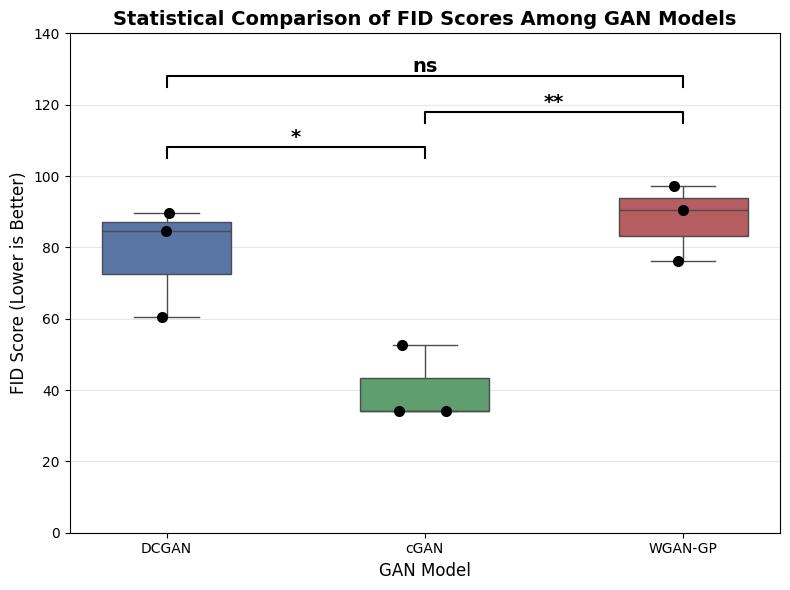

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# ==========================
# Prepare Data
# ==========================

df = pd.DataFrame({
    "FID": dcgan_fid + cgan_fid + wgan_fid,
    "Model": (
        ["DCGAN"]*3 +
        ["cGAN"]*3 +
        ["WGAN-GP"]*3
    )
})


# ==========================
# Plot
# ==========================

plt.figure(figsize=(8,6))

palette = {
    "DCGAN": "#4C72B0",
    "cGAN": "#55A868",
    "WGAN-GP": "#C44E52"
}


ax = sns.boxplot(
    data=df,
    x="Model",
    y="FID",
    palette=palette,
    width=0.5
)


# show individual runs
sns.stripplot(
    data=df,
    x="Model",
    y="FID",
    color="black",
    size=8,
    jitter=True
)


plt.ylabel("FID Score (Lower is Better)", fontsize=12)
plt.xlabel("GAN Model", fontsize=12)

plt.title(
    "Statistical Comparison of FID Scores Among GAN Models",
    fontsize=14,
    fontweight="bold"
)


# ==========================
# Tukey Significance Lines
# ==========================

def add_significance(ax, x1, x2, y, h, text):

    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5,
        c="black"
    )

    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )


# Highest y position
y_max = df["FID"].max()

# DCGAN vs cGAN
add_significance(
    ax,
    0,
    1,
    105,
    3,
    "*"
)

# cGAN vs WGAN-GP
add_significance(
    ax,
    1,
    2,
    115,
    3,
    "**"
)

# DCGAN vs WGAN-GP
add_significance(
    ax,
    0,
    2,
    125,
    3,
    "ns"
)


plt.ylim(0,140)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

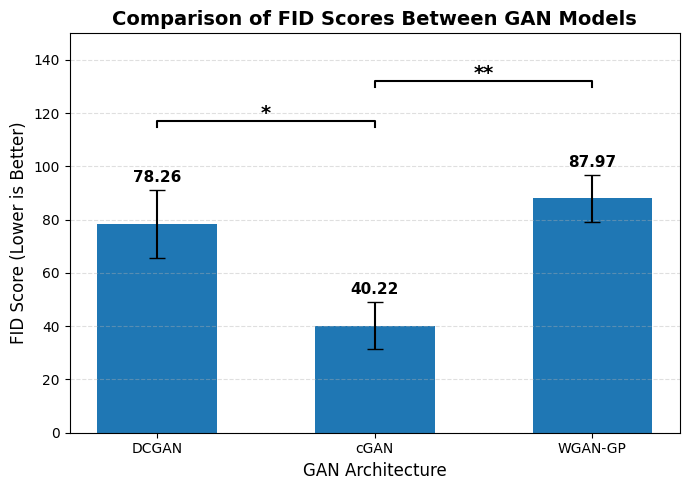

In [38]:
import numpy as np
import matplotlib.pyplot as plt


# ===============================
# Data
# ===============================

models = ["DCGAN", "cGAN", "WGAN-GP"]

fid_scores = [
    dcgan_fid,
    cgan_fid,
    wgan_fid
]

means = [np.mean(x) for x in fid_scores]
stds  = [np.std(x) for x in fid_scores]


# ===============================
# Plot
# ===============================

fig, ax = plt.subplots(figsize=(7,5))


bars = ax.bar(
    models,
    means,
    yerr=stds,
    capsize=6,
    width=0.55
)


# Add values on top of bars

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        mean+stds[bars.index(bar)]+3,
        f"{mean:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# ===============================
# Tukey Significance Markers
# ===============================

def significance_line(x1,x2,y,text):

    ax.plot(
        [x1,x1,x2,x2],
        [y,y+2,y+2,y],
        linewidth=1.5,
        color="black"
    )

    ax.text(
        (x1+x2)/2,
        y+3,
        text,
        ha="center",
        fontsize=14,
        fontweight="bold"
    )


# significant only

# DCGAN vs cGAN
significance_line(
    0,
    1,
    115,
    "*"
)

# cGAN vs WGAN-GP
significance_line(
    1,
    2,
    130,
    "**"
)


# ===============================
# Formatting
# ===============================

ax.set_ylabel(
    "FID Score (Lower is Better)",
    fontsize=12
)

ax.set_xlabel(
    "GAN Architecture",
    fontsize=12
)

ax.set_title(
    "Comparison of FID Scores Between GAN Models",
    fontsize=14,
    fontweight="bold"
)


ax.set_ylim(0,150)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)


plt.tight_layout()
plt.show()

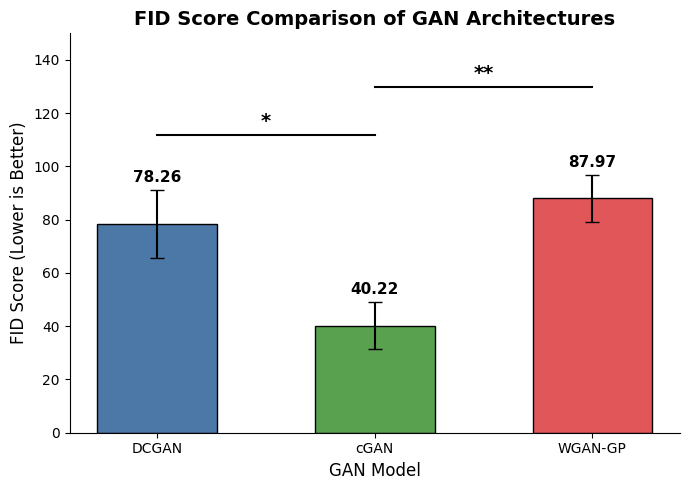

In [41]:
import numpy as np
import matplotlib.pyplot as plt


# ===============================
# Data
# ===============================

models = ["DCGAN", "cGAN", "WGAN-GP"]

fid_scores = [
    dcgan_fid,
    cgan_fid,
    wgan_fid
]

means = [np.mean(x) for x in fid_scores]
stds  = [np.std(x) for x in fid_scores]


# ===============================
# Plot
# ===============================

fig, ax = plt.subplots(figsize=(7,5))


# Different colors
colors = [
    "#4C78A8",   # DCGAN blue
    "#59A14F",   # cGAN green
    "#E15759"    # WGAN red
]


bars = ax.bar(
    models,
    means,
    yerr=stds,
    capsize=5,
    width=0.55,
    color=colors,
    edgecolor="black",
    linewidth=1
)


# Add mean values

for i, bar in enumerate(bars):

    ax.text(
        bar.get_x()+bar.get_width()/2,
        means[i]+stds[i]+3,
        f"{means[i]:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# ===============================
# Tukey Significance Brackets
# (No vertical lines)
# ===============================

def add_sig(ax, x1, x2, y, text):

    ax.plot(
        [x1, x2],
        [y, y],
        linewidth=1.5,
        color="black"
    )

    ax.text(
        (x1+x2)/2,
        y+3,
        text,
        ha="center",
        fontsize=14,
        fontweight="bold"
    )


# DCGAN vs cGAN
add_sig(
    ax,
    0,
    1,
    112,
    "*"
)


# cGAN vs WGAN-GP
add_sig(
    ax,
    1,
    2,
    130,
    "**"
)


# ===============================
# Formatting
# ===============================

ax.set_ylabel(
    "FID Score (Lower is Better)",
    fontsize=12
)

ax.set_xlabel(
    "GAN Model",
    fontsize=12
)


ax.set_title(
    "FID Score Comparison of GAN Architectures",
    fontsize=14,
    fontweight="bold"
)


ax.set_ylim(0,150)


# cleaner background
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.grid(
    axis="y",
    linestyle="",
    alpha=0.3
)


plt.tight_layout()

plt.show()